# Hab Dishab Sanbox Analysis

Answering random questions

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

from trial_class import *
from experiment_class import Experiment
from bouts_extension import *


In [2]:
# NAc: #15616F
# mPFC: #FFAF00

# experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac"
# csv_base_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\nac_csvs"
# brain_region = '#15616F'

# experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc"
# csv_base_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Hab_Dishab\All\mpfc_csvs"
# brain_region = '#FFAF00'

experiment_path = "/Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/nac"
csv_base_path = "/Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all_csvs/nac_csvs"
brain_region = '#15616F'

# experiment_path = "/Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/mpfc"
# csv_base_path = "/Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all_csvs/mpfc_csvs"
# brain_region = '#FFAF00'


save_images = False

In [3]:
bout_definitions = [
    {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
    {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'}
]

In [4]:
# groups csv + experiment data into one variable
experiment = Experiment(experiment_path, csv_base_path)

# batch process the data, removing the specified time segments for subjects
experiment.default_batch_process()

Found Synapse note file: /Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/nac/n7-240821-114717/Notes.txt
read from t=0s to t=1309.86s
Found Synapse note file: /Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/nac/nn7-250114-100133/Notes.txt
read from t=0s to t=1376.66s
Found Synapse note file: /Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/nac/nn3-250115-064154/Notes.txt
read from t=0s to t=1377.67s
Found Synapse note file: /Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/nac/n6-240821-100116/Notes.txt
read from t=0s to t=1335.06s
Found Synapse note file: /Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/nac/nn1-250115-052028/Notes.txt
read from t=0s to t=1351.05s
Found Synapse note file: /Users/naylajimenez/Downloads/papers/dopamine/cohort-1-2/allcohorts/C1_2_3_Hab Dishab/all/nac/nn4

### Check if there is a second behavioral event when you take the peak nearest to first investigation. We want to ensure you are not taking the peak of a second behavioral event.

In [5]:
experiment.reset_all_behaviors()
experiment.group_extract_manual_annotations(bout_definitions=bout_definitions, first_only = False)

# total_avg_bout_duration = metadata_df["Average Bout Duration"].mean()
# print(f"Total Average Bout Duration: {total_avg_bout_duration:.4f}")
# Proceed with DA metric computation after all files are processed
experiment.compute_all_da_metrics(use_max_length=False,
                                  max_bout_duration=4, # total_avg_bout_duration 
                                  mode='standard')

Processing behaviors for n7-240821-114717...
Processing behaviors for nn7-250114-100133...
Processing behaviors for nn3-250115-064154...
Processing behaviors for n6-240821-100116...
Processing behaviors for nn1-250115-052028...
Processing behaviors for nn4-250115-072812...
Processing behaviors for nn2-250115-054951...
Processing behaviors for nn5-250114-083827...
Processing behaviors for n5-240821-085040...
Processing behaviors for nn6-250114-093117...
Processing behaviors for nn8-250114-103839...
Computing DA metrics for n7-240821-114717 ...
Computing DA metrics for nn7-250114-100133 ...
Computing DA metrics for nn3-250115-064154 ...
Computing DA metrics for n6-240821-100116 ...
Computing DA metrics for nn1-250115-052028 ...
Computing DA metrics for nn4-250115-072812 ...
Computing DA metrics for nn2-250115-054951 ...
Computing DA metrics for nn5-250114-083827 ...
Computing DA metrics for n5-240821-085040 ...
Computing DA metrics for nn6-250114-093117 ...
Computing DA metrics for nn8-2

In [6]:
exp_da_dict = get_trial_dataframes(experiment)
desired_bouts = ['s1-1', 's1-2', 's1-3', 's1-4', 's1-5', 's2-1']

In [7]:
def count_peaks_past_next_investigation(exp_da_dict, behavior="Investigation"):
    """
    For each subject and bout, check if the first behavior's peak occurs
    after the second behavior's onset. Returns a nested dict:
    
    {
      subject_id: {
        bout_label: {
          "overlap": True/False,
          "absolute_peak_time": float,
          "second_onset": float
        },
        ...
      },
      ...
    }
    """
    from collections import defaultdict

    overlaps = defaultdict(dict)

    for subj, df in exp_da_dict.items():
        df_b = df[df["Behavior"] == behavior].copy()
        df_b.sort_values("Event_Start", inplace=True)

        for bout, g in df_b.groupby("Bout"):
            g = g.reset_index(drop=True)

            if len(g) < 2:
                overlaps[subj][bout] = {
                    "overlap": False,
                    "absolute_peak_time": None,
                    "second_onset": None
                }
                continue

            first = g.loc[0]
            second_onset = g.loc[1, "Event_Start"]
            absolute_peak_time = first["Event_Start"] + first["Time of Max Peak"]

            overlaps[subj][bout] = {
                "overlap": absolute_peak_time > second_onset,
                "absolute_peak_time": absolute_peak_time,
                "second_onset": second_onset
            }

    return overlaps


In [8]:
overlaps = count_peaks_past_next_investigation(exp_da_dict)

In [9]:
for subj, bouts in overlaps.items():
    for bout, info in bouts.items():
        if info["overlap"]:
            print(f"⚠️ {subj} / {bout}: 1st peak ({info['absolute_peak_time']:.2f}s) ≥ 2nd onset ({info['second_onset']:.2f}s)")


⚠️ nn6 / s1-1: 1st peak (190.99s) ≥ 2nd onset (189.60s)


In [10]:
# exp_da_dict['nn6']

### Quantify frequency of dopamine peaks throughout time, since the mPFC DA preprint shows that frequency was higher for novel contexts. 

In [11]:
bout_defs = [
    {'prefix':'s1', 'introduced':'s1_Introduced', 'removed':'s1_Removed'},
    {'prefix':'s2', 'introduced':'s2_Introduced', 'removed':'s2_Removed'},
]

bout_bounds_df = experiment.get_bout_boundaries_df(bout_defs)
print(bout_bounds_df.head())


  Subject  Bout  Bout_Start_s  Bout_End_s
0      n7  s1-1         184.5       306.2
1      n7  s1-2         374.2       492.1
2      n7  s1-3         558.9       679.5
3      n7  s1-4         746.8       867.3
4      n7  s1-5         936.9      1059.8


In [12]:
# 1) Get bout definitions and boundaries
bout_defs = [
    {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
    {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'},
]
bout_bounds_df = experiment.get_bout_boundaries_df(bout_defs)

# 2) Plot traces with both behavior spans and bout markers
# experiment.plot_behavior_and_bouts(bout_bounds_df, behavior_name="Investigation")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def detect_spontaneous_events(
    timestamps: np.ndarray,
    signal: np.ndarray,
    threshold_factor: float = 3.0,
    min_distance_s: float = 1.0,
    min_width_s:    float = 0.5
):
    """
    Detect peaks using a MAD‐threshold, plus a minimum inter‐peak interval
    and a minimum peak width.
    Returns:
      peak_times (np.ndarray),
      peak_amps (np.ndarray),
      peak_widths (np.ndarray, in seconds)
    """
    # 1) compute baseline + MAD
    med = np.median(signal)
    mad = np.median(np.abs(signal - med))
    thresh = med + threshold_factor * mad

    # 2) convert time criteria into sample counts (assumes uniform dt)
    dt = np.median(np.diff(timestamps))
    min_dist_samples  = int(np.round(min_distance_s / dt))
    min_width_samples = int(np.round(min_width_s    / dt))

    # 3) detect peaks
    peaks, props = find_peaks(
        signal,
        height=thresh,
        distance=min_dist_samples,
        width=min_width_samples
    )

    # 4) collect outputs
    peak_times  = timestamps[peaks]
    peak_amps   = signal[peaks]
    peak_widths = props["widths"] * dt

    return peak_times, peak_amps, peak_widths

def build_event_dataframe(
    experiment,
    threshold_factor: float = 3.0,
    min_distance_s:    float = 1.0,
    min_width_s:       float = 0.5
) -> pd.DataFrame:
    """
    Loop through experiment.trials, run detect_spontaneous_events on each trial,
    and return a DataFrame with columns:
      Subject | Trial | Event_Time | Amplitude | Width_s
    """
    rows = []
    for trial_name, trial in experiment.trials.items():
        ts  = np.array(trial.timestamps)
        sig = np.array(trial.zscore)   # or trial.dff if you prefer raw ΔF/F

        peak_times, peak_amps, peak_widths = detect_spontaneous_events(
            ts, sig,
            threshold_factor=threshold_factor,
            min_distance_s=min_distance_s,
            min_width_s=min_width_s
        )

        for t, a, w in zip(peak_times, peak_amps, peak_widths):
            rows.append({
                "Subject":    trial.subject_name,
                "Trial":      trial_name,
                "Event_Time": t,
                "Amplitude":  a,
                "Width_s":    w
            })

    return pd.DataFrame(rows)


def plot_all_traces_with_bouts_and_peaks(
    experiment,
    bout_bounds_df: pd.DataFrame,
    peaks_df: pd.DataFrame = None,
    behavior_name: str = "all",
    start_time: float = 30.0
):
    """
    Plots each trial's z-score with:
    - behavior spans (green for Investigation, gray for others),
    - lightly shaded blue spans for each bout,
    - optional red dots for spontaneous events (peaks_df).

    Parameters:
    - experiment: Experiment instance containing trials
    - bout_bounds_df: DataFrame with Subject, Bout_Start_s, and Bout_End_s
    - peaks_df: Optional DataFrame with Trial and Event_Time (and Amplitude)
    - behavior_name: Name of the behavior to span ("all" for all)
    - start_time: Minimum x-axis time for plotting
    """
    num_trials = len(experiment.trials)
    fig, axes = plt.subplots(nrows=num_trials,
                             figsize=(12, 3 * num_trials),
                             sharex=False)
    if num_trials == 1:
        axes = [axes]

    for ax, (trial_name, trial) in zip(axes, experiment.trials.items()):
        ax.set_title(trial_name)

        # 1. Plot z-score
        ax.plot(trial.timestamps, trial.zscore, color="black", lw=1, label="z-score")

        # 2. Behavior spans
        dfb = trial.behaviors
        if dfb is not None and not dfb.empty:
            if behavior_name != "all":
                dfb = dfb[dfb["Behavior"] == behavior_name]
            for _, row in dfb.iterrows():
                color = "green" if row["Behavior"] == "Investigation" else "gray"
                ax.axvspan(row["Event_Start"], row["Event_End"], color=color, alpha=0.3)

        # 3. Lightly shaded bouts in blue
        bounds = bout_bounds_df[bout_bounds_df["Subject"] == trial.subject_name]
        for _, row in bounds.iterrows():
            ax.axvspan(row["Bout_Start_s"], row["Bout_End_s"], color="skyblue", alpha=0.3)

        # 4. Peak events
        if peaks_df is not None:
            ev = peaks_df[peaks_df["Trial"] == trial_name]
            ax.scatter(ev["Event_Time"],
                       ev["Amplitude"],
                       color="red",
                       s=30,
                       zorder=5,
                       label="Peaks")

        # 5. Final formatting
        ax.set_xlim(start_time, trial.timestamps[-1])
        ax.tick_params(axis='x', labelbottom=True)
        ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()


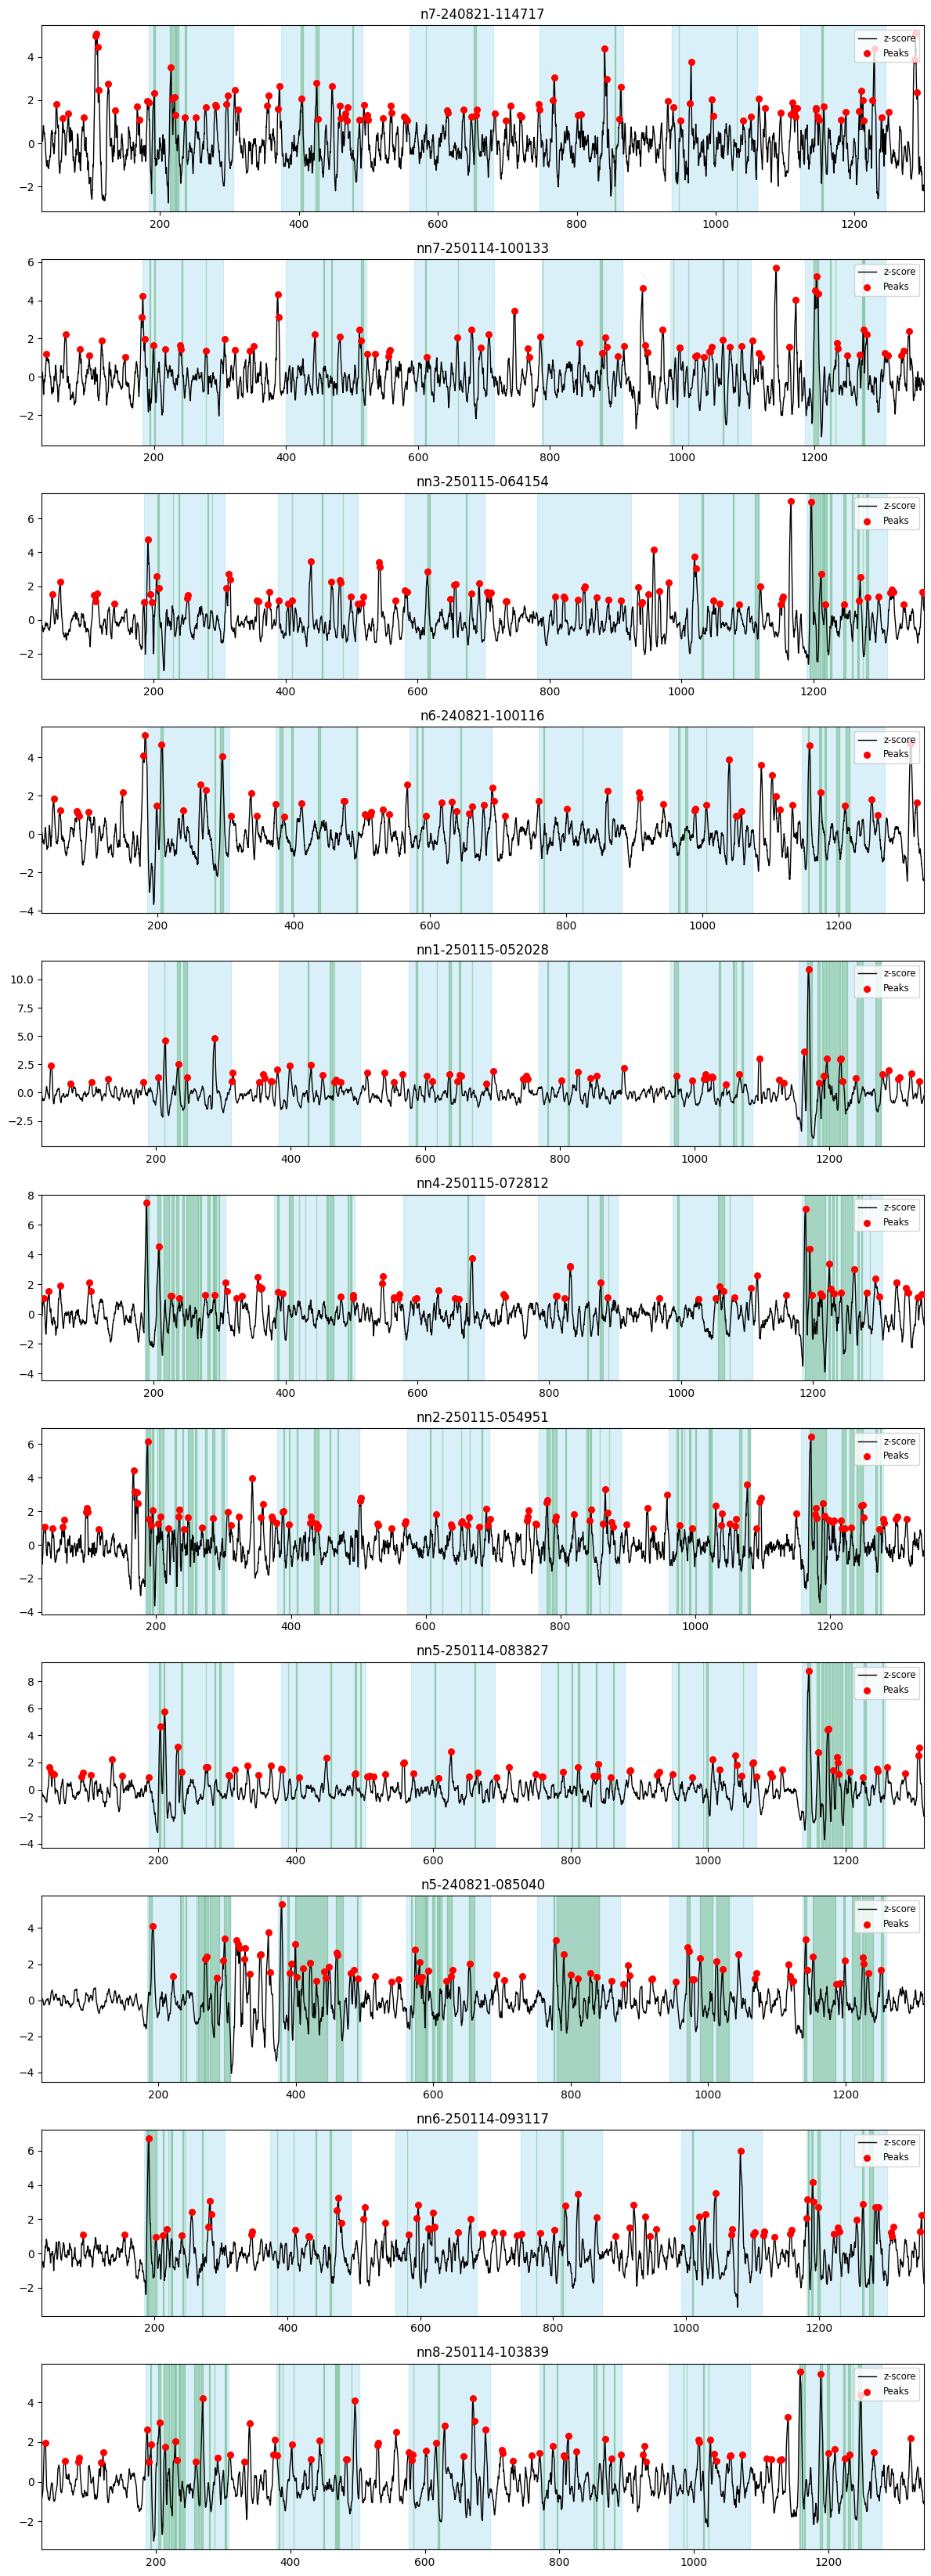

In [14]:
bout_defs = [
    {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
    {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'}
]

bout_bounds_df = experiment.get_bout_boundaries_df(bout_defs)
peaks_df = build_event_dataframe(experiment,   
                                threshold_factor=3.5,   # e.g. 2.5 × MAD
                                min_distance_s=0.5,     # at least 1 second between peaks
                                min_width_s=0.3         # each peak ≥ 0.3 s wide
)


plot_all_traces_with_bouts_and_peaks(experiment, bout_bounds_df, peaks_df, behavior_name='Investigation')


In [15]:
peaks_df

,Subject,Trial,Event_Time,Amplitude,Width_s
0,n7,n7-240821-114717,50.910658,1.797793,5.348259
1,n7,n7-240821-114717,60.278046,1.171778,3.895909
2,n7,n7-240821-114717,68.233788,1.370458,9.119392
3,n7,n7-240821-114717,90.137885,1.202127,4.478264
4,n7,n7-240821-114717,107.521964,4.944262,0.355797
...,...,...,...,...,...
930,nn8,nn8-250114-103839,1140.383394,3.244376,4.520978
931,nn8,nn8-250114-103839,1158.464448,5.536537,4.902113
932,nn8,nn8-250114-103839,1248.369352,4.388006,4.405545
933,nn8,nn8-250114-103839,1267.735240,1.471724,6.445543


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Build a little table of recording durations per subject
#    (each trial’s duration minus the first 30 s)
rows = []
for trial_name, trial in experiment.trials.items():
    subj = trial.subject_name
    # total trial time (s) after cutting out the first 30 s
    dur_s = trial.timestamps[-1] - 30.0
    rows.append({'Subject': subj, 'Duration_s': dur_s})
dur_df = pd.DataFrame(rows)

# 2) Sum durations across trials for each subject, convert to minutes
time_per_subj = (
    dur_df
    .groupby('Subject', as_index=False)['Duration_s']
    .sum()
    .assign(Duration_min = lambda df: df['Duration_s'] / 60)
)

# 3) Count peaks per subject (only those after 30 s)
counts = (
    peaks_df[peaks_df['Event_Time'] >= 30]
    .groupby('Subject', as_index=False)
    .size()
    .rename(columns={'size':'Num_Peaks'})
)

# 4) Merge counts & total time → compute rate
rate_df = pd.merge(counts, time_per_subj, on='Subject')
rate_df['Peaks_per_min'] = rate_df['Num_Peaks'] / rate_df['Duration_min']

print(rate_df)


   Subject  Num_Peaks   Duration_s  Duration_min  Peaks_per_min
0       n5         86  1283.972525     21.399542       4.018778
1       n6         66  1294.919659     21.581994       3.058105
2       n7        109  1269.753835     21.162564       5.150605
3      nn1         71  1311.025786     21.850430       3.249364
4      nn2        117  1309.767494     21.829458       5.359730
5      nn3         88  1337.575729     22.292929       3.947440
6      nn4         76  1338.582362     22.309706       3.406589
7      nn5         83  1284.350013     21.405834       3.877448
8      nn6         81  1328.138546     22.135642       3.659257
9      nn7         79  1336.443267     22.274054       3.546727
10     nn8         79  1312.661564     21.877693       3.610984


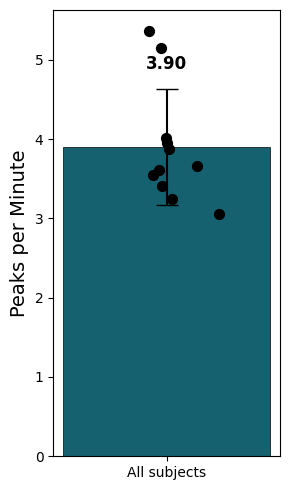

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- assume you already have rate_df
mean_rate = rate_df['Peaks_per_min'].mean()
std_rate  = rate_df['Peaks_per_min'].std(ddof=1)

fig, ax = plt.subplots(figsize=(3, 5))

# 1) draw bar with error bar
bar_x = 0
bar_width = 0.25
ax.bar(bar_x, mean_rate,
       yerr=std_rate,
       capsize=8,
       width=bar_width,
       color=brain_region,
       edgecolor='black',
       linewidth=0.5)

# 2) add mean value as text above the bar
ax.text(bar_x, mean_rate + std_rate + 0.2, f"{mean_rate:.2f}",
        ha='center', va='bottom', fontsize=12, fontweight='bold')

# 3) overlay individual subject dots (with slight jitter)
x_jitter = np.random.normal(bar_x, 0.03, size=len(rate_df))
ax.scatter(x_jitter, rate_df['Peaks_per_min'],
           color='black', s=50, zorder=5)

# 4) cosmetics
ax.set_xticks([bar_x])
ax.set_xticklabels(['All subjects'])
ax.set_ylabel('Peaks per Minute', fontsize=14)
# ax.set_title('Spontaneous Event Rate', fontsize=16)

plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1) Build a little table of recording durations per subject
#    (each trial’s duration minus the first 30 s)
dur_rows = []
for trial_name, trial in experiment.trials.items():
    subj = trial.subject_name
    dur_s = trial.timestamps[-1] - 30.0
    dur_rows.append({'Subject': subj, 'Duration_s': dur_s})
dur_df = pd.DataFrame(dur_rows)

# 2) Sum durations across trials for each subject, convert to minutes
time_per_subj = (
    dur_df
    .groupby('Subject', as_index=False)['Duration_s']
    .sum()
    .assign(Duration_min=lambda df: df['Duration_s'] / 60)
)

# 3) Count investigation bouts per subject (only those after 30 s)
beh_rows = []
for trial_name, trial in experiment.trials.items():
    subj = trial.subject_name
    # filter only Investigation events in the manual annotations
    if trial.behaviors is not None and not trial.behaviors.empty:
        inv = trial.behaviors[
            (trial.behaviors['Behavior'] == 'Investigation') &
            (trial.behaviors['Event_Start'] >= 30)
        ]
        n_inv = len(inv)
    else:
        n_inv = 0
    beh_rows.append({'Subject': subj, 'Num_Behaviors': n_inv})
behav_df = pd.DataFrame(beh_rows)

# 4) Merge & compute behaviors per minute
behavior_df = pd.merge(behav_df, time_per_subj, on='Subject')
behavior_df['Behaviors_per_min'] = behavior_df['Num_Behaviors'] / behavior_df['Duration_min']

print(behavior_df)


   Subject  Num_Behaviors   Duration_s  Duration_min  Behaviors_per_min
0       n7             13  1269.753835     21.162564           0.614292
1      nn7             20  1336.443267     22.274054           0.897906
2      nn3             23  1337.575729     22.292929           1.031717
3       n6             20  1294.919659     21.581994           0.926698
4      nn1             25  1311.025786     21.850430           1.144142
5      nn4             36  1338.582362     22.309706           1.613647
6      nn2             46  1309.767494     21.829458           2.107244
7      nn5             32  1284.350013     21.405834           1.494920
8       n5             34  1283.972525     21.399542           1.588819
9      nn6             23  1328.138546     22.135642           1.039048
10     nn8             41  1312.661564     21.877693           1.874055


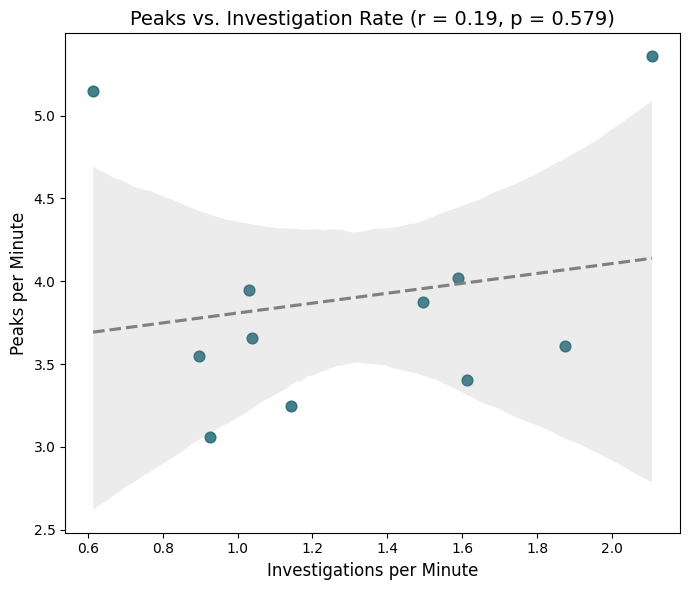

In [19]:
# merge your two rates
merged_df = pd.merge(rate_df, behavior_df[['Subject','Behaviors_per_min']], on='Subject')

plt.figure(figsize=(7,6))
sns.regplot(
    data=merged_df,
    x='Behaviors_per_min',
    y='Peaks_per_min',
    color=brain_region,               # use your region color
    scatter_kws={'s':60, 'alpha':0.8},
    line_kws={'linestyle':'--', 'color':'gray'}
)

# annotate Pearson r
r, p = pearsonr(merged_df['Behaviors_per_min'], merged_df['Peaks_per_min'])
plt.title(f'Peaks vs. Investigation Rate (r = {r:.2f}, p = {p:.3f})', fontsize=14)
plt.xlabel('Investigations per Minute', fontsize=12)
plt.ylabel('Peaks per Minute', fontsize=12)
plt.tight_layout()
plt.show()


In [20]:
import numpy as np
import pandas as pd

# 1) define your bout definitions & get boundaries
bout_defs = [
    {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
    {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'}
]
bout_bounds_df = experiment.get_bout_boundaries_df(bout_defs)

# 2) cut off first 30 s and restrict to peaks after that
peaks_cut = peaks_df[peaks_df.Event_Time >= 30].copy()

# 3) build per-subject rates
rows = []
for subj in peaks_cut.Subject.unique():
    subp   = peaks_cut[peaks_cut.Subject == subj]
    bounds = bout_bounds_df[bout_bounds_df.Subject == subj]\
                 .sort_values('Bout_Start_s')
    
    # --- Bout windows ---
    # total bout duration in seconds
    bout_dur_s = (bounds.Bout_End_s - bounds.Bout_Start_s).sum()
    # count of peaks inside any bout
    bout_count = sum(
        ((subp.Event_Time >= row.Bout_Start_s) & 
         (subp.Event_Time <= row.Bout_End_s)).sum()
        for _, row in bounds.iterrows()
    )
    # peaks per minute in‐bout
    rate_bout = bout_count / (bout_dur_s/60) if bout_dur_s>0 else np.nan

    # --- ITI windows (between end of this bout and start of next) ---
    iti_dur_s = 0
    iti_count = 0
    # get all the inter‐bout segments
    for i, row in enumerate(bounds.itertuples()):
        start = row.Bout_End_s
        # next bout’s start, or trial end if last
        if i+1 < len(bounds):
            end = bounds.iloc[i+1].Bout_Start_s
        else:
            # assume each trial is same length: grab max timestamp from any trial this subj
            trials = experiment.trials
            # find one trial for this subject:
            trial_name = next(n for n,t in trials.items() if t.subject_name==subj)
            end = experiment.trials[trial_name].timestamps[-1]
        iti_dur_s += (end - start)
        iti_count += ((subp.Event_Time > start) & (subp.Event_Time < end)).sum()

    rate_iti = iti_count / (iti_dur_s/60) if iti_dur_s>0 else np.nan

    rows.append({
        'Subject':    subj,
        'Rate_Bout':  rate_bout,
        'Rate_ITI':   rate_iti
    })

df = pd.DataFrame(rows)


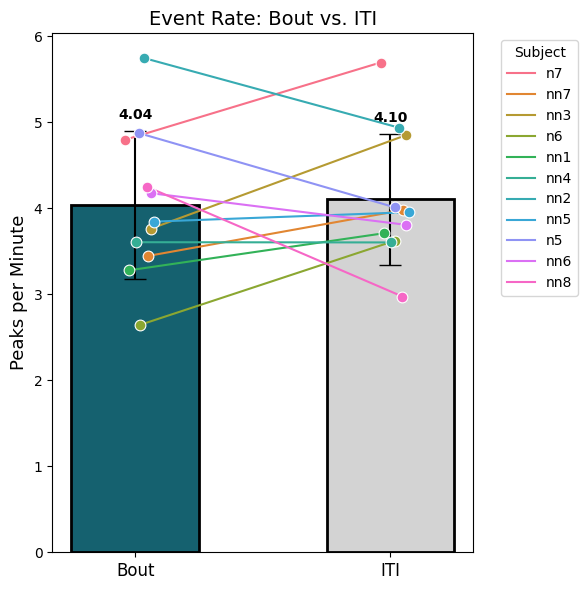

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# assume you already have:
#   peaks_df       with columns ['Subject','Trial','Event_Time',...]
#   bout_bounds_df with columns ['Subject','Bout_Start_s','Bout_End_s']
#   experiment     your Experiment instance
#   brain_region   your color for the "Bout" bar (e.g. '#15616F')

# — (steps 1–4 from before to build df with Rate_Bout & Rate_ITI) —

# ... [snip: same code to produce `df` with columns Subject, Rate_Bout, Rate_ITI] ...

# 5) compute means & stds
mean_bout = df['Rate_Bout'].mean()
std_bout  = df['Rate_Bout'].std(ddof=1)
mean_iti  = df['Rate_ITI'].mean()
std_iti   = df['Rate_ITI'].std(ddof=1)

# 6) color map for subjects
subjects = df['Subject'].unique()
palette = dict(zip(subjects, sns.color_palette("husl", len(subjects))))

# 7) plotting
fig, ax = plt.subplots(figsize=(6, 6))
bars_x = np.array([0, 1])
bar_w = 0.5

# draw bars
ax.bar(0, mean_bout, yerr=std_bout, capsize=8, width=bar_w,
       color=brain_region, edgecolor='black', linewidth=2)
ax.text(0, mean_bout + std_bout + 0.1, f"{mean_bout:.2f}",
        ha='center', va='bottom', fontweight='bold')

ax.bar(1, mean_iti, yerr=std_iti, capsize=8, width=bar_w,
       color='lightgray', edgecolor='black', linewidth=2)
ax.text(1, mean_iti + std_iti + 0.1, f"{mean_iti:.2f}",
        ha='center', va='bottom', fontweight='bold')

# overlay each subject: line + dots
for subj in subjects:
    row = df[df.Subject == subj].iloc[0]
    y_b = row['Rate_Bout']
    y_i = row['Rate_ITI']
    # small horizontal jitter so lines don’t perfectly overlap
    jitter = np.random.uniform(-0.08, 0.08)
    x_b, x_i = 0 + jitter, 1 + jitter

    # connect with a thin line
    ax.plot([x_b, x_i], [y_b, y_i],
            color=palette[subj], linewidth=1.5, zorder=4, label=subj)
    # draw end‐point markers
    ax.scatter([x_b, x_i], [y_b, y_i],
               color=palette[subj], s=60, edgecolor='white', linewidth=0.8, zorder=5)

# cosmetics & legend
ax.set_xticks(bars_x)
ax.set_xticklabels(['Bout', 'ITI'], fontsize=12)
ax.set_ylabel('Peaks per Minute', fontsize=13)
ax.set_title('Event Rate: Bout vs. ITI', fontsize=14)

# only one legend entry per subject
handles, labels = ax.get_legend_handles_labels()
# remove duplicates
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title='Subject', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In_Bout
True     542
False    393
Name: count, dtype: int64


/var/folders/tj/nfn3dynx2n19r7566d88xmsc0000gn/T/ipykernel_68856/4268827441.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='In_Bout', y='Amplitude', data=df,
/Users/naylajimenez/mambaforge3/envs/photometry/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/naylajimenez/mambaforge3/envs/photometry/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 26.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/naylajimenez/mambaforge3/envs/photometry/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 12.2% of the points cannot be placed; you may wa

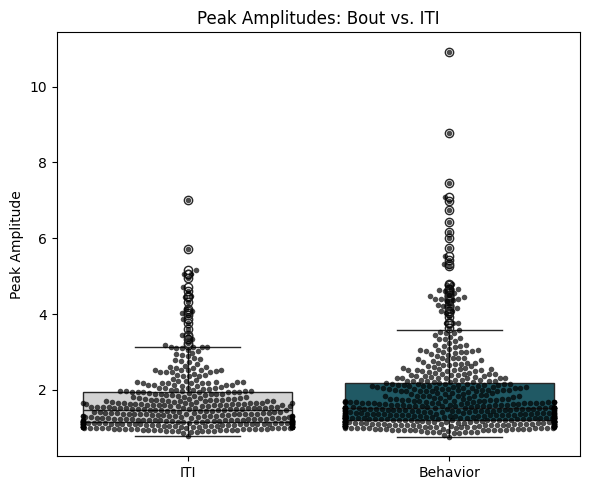

In_Bout     False     True 
Subject                    
n5       1.412939  1.685943
n6       1.535806  1.531645
n7       1.625548  1.600322
nn1      1.264049  1.483515
nn2      1.542165  1.487348
nn3      1.583199  1.396353
nn4      1.512634  1.330993
nn5      1.199757  1.441397
nn6      1.235387  1.770508
nn7      1.483952  1.602444
nn8      1.371826  1.507153
Wilcoxon p = 0.240


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# 1) Copy + label each peak as in‐bout or ITI
df = peaks_df.copy()
df['In_Bout'] = False

for _, br in bout_bounds_df.iterrows():
    m = (
      (df['Subject'] == br['Subject']) &
      (df['Event_Time'] >= br['Bout_Start_s']) &
      (df['Event_Time'] <= br['Bout_End_s'])
    )
    df.loc[m, 'In_Bout'] = True

# sanity check
print(df['In_Bout'].value_counts())

# 2) Plot amplitude distributions
plt.figure(figsize=(6,5))
sns.boxplot(x='In_Bout', y='Amplitude', data=df,
            palette=['lightgray', brain_region])
sns.swarmplot(x='In_Bout', y='Amplitude', data=df,
              color='k', alpha=0.7, size=4)

plt.xticks([0,1], ['ITI','Behavior'])
plt.ylabel('Peak Amplitude')
plt.xlabel('')
plt.title('Peak Amplitudes: Bout vs. ITI')
plt.tight_layout()
plt.show()

# 3) (Optional) Paired summary per subject and test
#    Compute each mouse’s median amplitude in‐bout vs ITI
subj_stats = df.groupby(['Subject','In_Bout'])['Amplitude']\
               .median()\
               .unstack()

print(subj_stats)

# paired Wilcoxon signed‐rank test
stat, p = wilcoxon(subj_stats[False], subj_stats[True])
print(f"Wilcoxon p = {p:.3f}")


In [23]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # — your existing `count_df` DataFrame of shape (3 conditions × N subjects)
# #    index = ['Intro','Removal','Combined'], columns = [subj1, subj2, …]

# # 1) for each subject, get its peaks (after the 30 s cut)
# subjects = peaks_df['Subject'].unique()
# before_win = 3
# after_win  = 1

# counts = {'Intro':{}, 'Removal':{}, 'Combined':{}}

# for subj in subjects:
#     # all peaks for this mouse
#     subp = peaks_df[(peaks_df.Subject==subj)]
#     # all the intro/removal times
#     bb = bout_bounds_df[bout_bounds_df.Subject==subj]

#     # count around each intro:
#     n_intro = 0
#     for t0 in bb['Bout_Start_s']:
#         n_intro += np.sum((subp.Event_Time >= t0 - before_win) & (subp.Event_Time <= t0 + after_win))

#     # count around each removal:
#     n_rem = 0
#     for t1 in bb['Bout_End_s']:
#         n_rem += np.sum((subp.Event_Time >= t1 - before_win) & (subp.Event_Time <= t1 + after_win))

#     counts['Intro'][subj]    = n_intro
#     counts['Removal'][subj]  = n_rem
#     counts['Combined'][subj] = n_intro + n_rem

# # 2) build a DataFrame: index=conditions, columns=subjects
# count_df = pd.DataFrame(counts).T  # now rows Intro/Removal/Combined, cols each subject
# count_df = pd.DataFrame(counts).T  # shape (3, n_subjects)
# conditions = count_df.index.tolist()
# subjects   = count_df.columns.tolist()


# conditions = count_df.index.tolist()
# subjects   = count_df.columns.tolist()
# N = len(subjects)

# # mean per condition
# mean_counts = count_df.mean(axis=1)

# # pick N truly distinct colors
# cmap = plt.cm.get_cmap("tab20", N)
# subject_colors = {subj: cmap(i) for i, subj in enumerate(subjects)}

# # --- plotting
# fig, ax = plt.subplots(figsize=(6,5))
# x = np.arange(len(conditions))
# bar_width = 0.8

# # 1) draw the light gray bars for the mean
# ax.bar(
#     x, mean_counts,
#     width=bar_width,
#     color="lightgray",
#     edgecolor="black",
#     linewidth=1.5
# )

# # 2) connect each subject’s three points
# for subj in subjects:
#     y = count_df[subj].values
#     ax.plot(
#         x, y,
#         color=subject_colors[subj],
#         linewidth=2,
#         alpha=0.8,
#         zorder=3
#     )

# # 3) overlay each mouse’s dot (with minimal horizontal jitter)
# for i, cond in enumerate(conditions):
#     for subj in subjects:
#         y = count_df.loc[cond, subj]
#         jitter = np.random.uniform(-bar_width*0.02, bar_width*0.02)
#         ax.scatter(
#             i + jitter, y,
#             color=subject_colors[subj],
#             s=80,
#             edgecolor="black",
#             linewidth=0.5,
#             zorder=4,
#             label=subj  # will dedupe next
#         )

# # 4) build a clean legend (one entry per mouse)
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(
#     by_label.values(),
#     by_label.keys(),
#     title="Subject",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )

# # 5) labels & cosmetics
# ax.set_xticks(x)
# ax.set_xticklabels(conditions, fontsize=12)
# ax.set_ylabel("Number of Peaks (–3 to +1 s)", fontsize=12)
# ax.set_title("Peaks around Agent Intro vs. Removal", fontsize=14)
# plt.tight_layout()
# plt.show()


In [24]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1) Build percentage counts per subject
# subjects = peaks_df['Subject'].unique()
# before_win = 3
# after_win  = 1

# percents = {'Intro': {}, 'Removal': {}, 'Combined': {}}

# for subj in subjects:
#     # peaks after the 30 s cutoff
#     subp = peaks_df[(peaks_df.Subject == subj) & (peaks_df.Event_Time >= 30)]
#     total_peaks = len(subp)
#     bb = bout_bounds_df[bout_bounds_df.Subject == subj]

#     # count intro‐aligned peaks
#     n_intro = sum(
#         ((subp.Event_Time >= t0 - before_win) & (subp.Event_Time <= t0 + after_win)).sum()
#         for t0 in bb['Bout_Start_s']
#     )
#     # count removal‐aligned peaks
#     n_removal = sum(
#         ((subp.Event_Time >= t1 - before_win) & (subp.Event_Time <= t1 + after_win)).sum()
#         for t1 in bb['Bout_End_s']
#     )

#     if total_peaks > 0:
#         percents['Intro'][subj]    = n_intro      / total_peaks * 100
#         percents['Removal'][subj]  = n_removal    / total_peaks * 100
#         percents['Combined'][subj] = (n_intro + n_removal) / total_peaks * 100
#     else:
#         # no peaks → set 0%
#         percents['Intro'][subj]    = 0
#         percents['Removal'][subj]  = 0
#         percents['Combined'][subj] = 0

# # 2) Build DataFrame
# count_df = pd.DataFrame(percents).T  # index = ['Intro','Removal','Combined'], cols = subjects
# conditions = count_df.index.tolist()
# subjects   = count_df.columns.tolist()
# N = len(subjects)

# # 3) Compute means
# mean_perc = count_df.mean(axis=1)

# # 4) Choose a distinct color per subject
# cmap = plt.cm.get_cmap("tab20", N)
# subject_colors = {subj: cmap(i) for i, subj in enumerate(subjects)}

# # 5) Plot
# fig, ax = plt.subplots(figsize=(6, 5))
# x = np.arange(len(conditions))
# bar_width = 0.6

# # a) Bars for the mean percentages
# ax.bar(
#     x, mean_perc,
#     width=bar_width,
#     color="lightgray",
#     edgecolor="black",
#     linewidth=2
# )

# # b) Lines connecting each subject’s values
# for subj in subjects:
#     y = count_df[subj].values
#     ax.plot(
#         x, y,
#         color=subject_colors[subj],
#         linewidth=2.5,
#         alpha=0.8,
#         zorder=3
#     )

# # c) Dots for each subject
# for i, cond in enumerate(conditions):
#     for subj in subjects:
#         y = count_df.loc[cond, subj]
#         jitter = np.random.uniform(-bar_width*0.02, bar_width*0.02)
#         ax.scatter(
#             i + jitter, y,
#             color=subject_colors[subj],
#             s=80,
#             edgecolor="black",
#             linewidth=0.8,
#             zorder=4,
#             label=subj
#         )

# # d) Legend: one entry per subject
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(
#     by_label.values(),
#     by_label.keys(),
#     title="Subject",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False
# )

# # e) Labels & cosmetics
# ax.set_xticks(x)
# ax.set_xticklabels(conditions, fontsize=12)
# ax.set_ylabel("Peaks (% of Total)    ", fontsize=12)
# ax.set_title("Peaks Near Agent Intro vs. Removal\n(as % of each subject’s total)", fontsize=14)
# plt.tight_layout()
# plt.show()


In [25]:
def compute_peak_rates(
    peaks_df: pd.DataFrame,
    bout_bounds_df: pd.DataFrame,
    event_type: str,
    before_win: float,
    after_win: float = 1.0,
    cutoff_s: float = 30.0
) -> pd.Series:
    """
    Returns peaks per second around each Entry or Removal.
    For each subject:
      - window length = before_win + after_win
      - total_time = n_events * window_length
      - rate = count_peaks_in_windows / total_time
    """
    assert event_type in ('Entry','Removal')
    subjects = peaks_df['Subject'].unique()
    rates = {}
    window_len = before_win + after_win

    for subj in subjects:
        subp = peaks_df[
            (peaks_df.Subject == subj) &
            (peaks_df.Event_Time >= cutoff_s)
        ]
        # grab each event’s timestamp
        bb = bout_bounds_df[bout_bounds_df.Subject == subj]
        times = bb['Bout_Start_s'] if event_type=='Entry' else bb['Bout_End_s']
        n_events = len(times)
        if n_events == 0 or window_len <= 0:
            rates[subj] = 0.0
            continue

        # count how many peaks fall in any of the windows
        count = 0
        for t in times:
            m = (subp.Event_Time >= t - before_win) & (subp.Event_Time <= t + after_win)
            count += m.sum()

        total_time = n_events * window_len
        rates[subj] = count / total_time

    return pd.Series(rates, name=event_type)


/var/folders/tj/nfn3dynx2n19r7566d88xmsc0000gn/T/ipykernel_68856/4195324089.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap       = plt.cm.get_cmap('tab20', len(subjects))


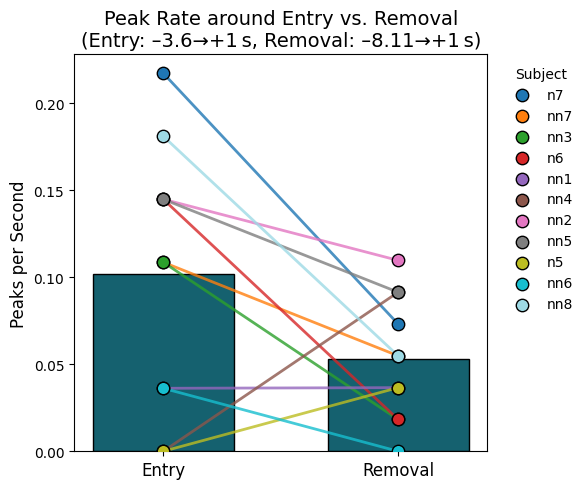

In [26]:
entry_rate   = compute_peak_rates(peaks_df, bout_bounds_df,
                                  event_type='Entry',
                                  before_win=3.6,
                                  after_win=1.0)

removal_rate = compute_peak_rates(peaks_df, bout_bounds_df,
                                  event_type='Removal',
                                  before_win=8.11,
                                  after_win=1.0)

# combine
df_rate = pd.concat([entry_rate, removal_rate], axis=1)
conditions = df_rate.columns.tolist()   # ['Entry','Removal']
subjects   = df_rate.index.tolist()
cmap       = plt.cm.get_cmap('tab20', len(subjects))
subject_colors = {s: cmap(i) for i,s in enumerate(subjects)}

fig, ax = plt.subplots(figsize=(6,5))
x = np.arange(len(conditions))
bar_w = 0.6

# gray bars = group means
means = df_rate.mean(axis=0)
ax.bar(x, means, width=bar_w, color=brain_region, edgecolor='k')

# lines + dots per subject
for subj in subjects:
    y = df_rate.loc[subj].values
    ax.plot(x, y, '-', color=subject_colors[subj], lw=2, alpha=0.8, zorder=3)
    ax.scatter(x, y,
               color=subject_colors[subj],
               edgecolor='k', s=80, zorder=4,
               label=subj)

# legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title='Subject',
          bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylabel('Peaks per Second', fontsize=12)
ax.set_title('Peak Rate around Entry vs. Removal\n(Entry: –3.6→+1 s, Removal: –8.11→+1 s)', fontsize=14)
plt.tight_layout()
plt.show()


In [27]:
# # reuse the same helper from before
# def compute_peak_percentages(
#     peaks_df: pd.DataFrame,
#     bout_bounds_df: pd.DataFrame,
#     event_type: str,
#     before_win: float,
#     after_win: float = 1.0,
#     cutoff_s: float = 30.0
# ) -> pd.Series:
#     """
#     Returns percent of each subject's total peaks that fall within
#     [–before_win, +after_win] around each Entry or Removal.
#     """
#     assert event_type in ('Entry','Removal')
#     subjects = peaks_df['Subject'].unique()
#     pct = {}
#     for subj in subjects:
#         subp = peaks_df[
#             (peaks_df.Subject == subj) &
#             (peaks_df.Event_Time >= cutoff_s)
#         ]
#         total = len(subp)
#         bb = bout_bounds_df[bout_bounds_df.Subject == subj]
#         times = bb['Bout_Start_s'] if event_type=='Entry' else bb['Bout_End_s']
#         count = 0
#         for t in times:
#             m = (subp.Event_Time >= t - before_win) & (subp.Event_Time <= t + after_win)
#             count += m.sum()
#         pct[subj] = (count/total*100) if total>0 else 0.0
#     return pd.Series(pct, name=event_type)

# # now compute with your new windows:
# entry_pct   = compute_peak_percentages(peaks_df, bout_bounds_df,
#                                        event_type='Entry',
#                                        before_win=3.6,
#                                        after_win=1.0)

# removal_pct = compute_peak_percentages(peaks_df, bout_bounds_df,
#                                        event_type='Removal',
#                                        before_win=8.11,
#                                        after_win=1.0)

# # combine into one table
# df_pct = pd.concat([entry_pct, removal_pct], axis=1)

# # plotting (same as before)
# conditions = df_pct.columns.tolist()   # ['Entry','Removal']
# subjects   = df_pct.index.tolist()
# N = len(subjects)
# cmap = plt.cm.get_cmap('tab20', N)
# subject_colors = {s: cmap(i) for i,s in enumerate(subjects)}

# fig, ax = plt.subplots(figsize=(6,5))
# x = np.arange(len(conditions))
# bar_w = 0.6

# # gray bars = group means
# means = df_pct.mean(axis=0)
# ax.bar(x, means, width=bar_w, color='lightgray', edgecolor='k')

# # lines + dots per mouse
# for subj in subjects:
#     y = df_pct.loc[subj].values
#     ax.plot(x, y, '-', color=subject_colors[subj], lw=2, alpha=0.8, zorder=3)
#     ax.scatter(x, y,
#                color=subject_colors[subj],
#                edgecolor='k', s=80, zorder=4,
#                label=subj)

# # legend
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(),
#           title='Subject',
#           bbox_to_anchor=(1.02,1), loc='upper left', frameon=False)

# ax.set_xticks(x)
# ax.set_xticklabels(conditions, fontsize=12)
# ax.set_ylabel('Peaks (% of total)', fontsize=12)
# ax.set_title('Peaks near Entry vs. Removal\n(Entry: –3.6→+1 s, Removal: –8.11→+1 s)', fontsize=14)
# plt.tight_layout()
# plt.show()


/var/folders/tj/nfn3dynx2n19r7566d88xmsc0000gn/T/ipykernel_68856/1262153657.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(subjects))


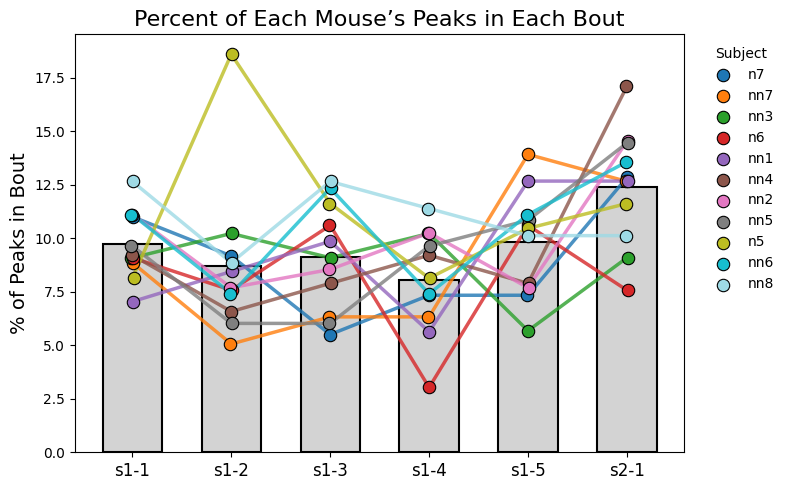

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Define which bouts to include, in order
bouts = ['s1-1', 's1-2', 's1-3', 's1-4', 's1-5', 's2-1']

# --- 2) Build a table of % peaks per bout per subject
subjects = peaks_df['Subject'].unique()
pct = {bout: {} for bout in bouts}

# ignore first 30 s
peaks_df = peaks_df[peaks_df.Event_Time >= 30]

for subj in subjects:
    subp = peaks_df[peaks_df.Subject == subj]
    total = len(subp)
    for bout in bouts:
        # get that subject’s boundaries for this bout
        bb = bout_bounds_df[
            (bout_bounds_df.Subject == subj) &
            (bout_bounds_df.Bout == bout)
        ]
        # count peaks inside any window (there should only be one row per bout)
        count = 0
        for _, row in bb.iterrows():
            count += ((subp.Event_Time >= row.Bout_Start_s) &
                      (subp.Event_Time <= row.Bout_End_s)).sum()
        pct[bout][subj] = (count / total * 100) if total else 0

# DataFrame: rows=bouts, cols=subjects
count_df = pd.DataFrame(pct).T  # shape (6, n_subjects)

# --- 3) Compute the mean % across subjects for each bout
mean_pct = count_df.mean(axis=1)

# --- 4) Pick distinct colors for each mouse
cmap = plt.cm.get_cmap("tab20", len(subjects))
subject_colors = {subj: cmap(i) for i, subj in enumerate(subjects)}

# --- 5) Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(bouts))
bar_w = 0.6

# a) gray bars = means
ax.bar(x, mean_pct, width=bar_w,
       color="lightgray", edgecolor="black", linewidth=1.5)

# b) lines connecting each mouse
for subj in subjects:
    y = count_df[subj].values
    ax.plot(x, y,
            color=subject_colors[subj],
            linewidth=2.5, alpha=0.8, zorder=3)

# c) colored dots for each mouse
for i, bout in enumerate(bouts):
    for subj in subjects:
        y = count_df.loc[bout, subj]
        jitter = np.random.uniform(-bar_w*0.02, bar_w*0.02)
        ax.scatter(i + jitter, y,
                   color=subject_colors[subj],
                   s=80, edgecolor="black", linewidth=0.8,
                   zorder=4, label=subj)

# d) legend (one entry per mouse)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title="Subject", bbox_to_anchor=(1.02,1),
          loc="upper left", frameon=False)

# e) labels & formatting
ax.set_xticks(x)
ax.set_xticklabels(bouts, fontsize=12)
ax.set_ylabel("% of Peaks in Bout", fontsize=14)
ax.set_title("Percent of Each Mouse’s Peaks in Each Bout", fontsize=16)
plt.tight_layout()
plt.show()


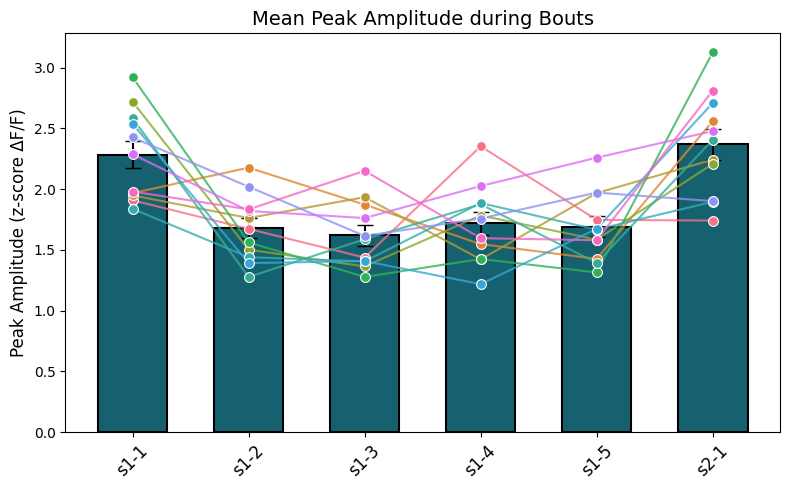

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1) set up your bouts & subjects ────────────────────────────────────────
bouts    = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']
subjects = peaks_df['Subject'].unique()

# ── 2) build a table of mean‐peak‐amplitude per bout per subject ─────────
amps   = {bout: {} for bout in bouts}
peaks_cut = peaks_df[peaks_df['Event_Time'] >= 30]  # drop first 30 s

for subj in subjects:
    subp = peaks_cut[peaks_cut['Subject'] == subj]
    for bout in bouts:
        # grab that mouse’s bout window(s)
        bb = bout_bounds_df[
            (bout_bounds_df['Subject'] == subj) &
            (bout_bounds_df['Bout']    == bout)
        ]
        # collect all the amplitudes that fall inside any of those rows
        vals = []
        for _, row in bb.iterrows():
            m = ((subp['Event_Time'] >= row['Bout_Start_s']) &
                 (subp['Event_Time'] <= row['Bout_End_s']))
            vals.extend(subp.loc[m, 'Amplitude'].tolist())
        # mean of those, or NaN if none
        amps[bout][subj] = np.nanmean(vals) if vals else np.nan

# turn into DataFrame: rows=subjects, cols=bouts
amp_df = pd.DataFrame(amps)

# ── 3) compute group mean ± SEM for each bout ───────────────────────────────
means = amp_df.mean(axis=0)
sems  = amp_df.sem(axis=0)

# ── 4) pick one color per mouse ────────────────────────────────────────────
palette = sns.color_palette("husl", len(subjects))
subject_colors = dict(zip(subjects, palette))

# ── 5) plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,5))
x     = np.arange(len(bouts))
bar_w = 0.6

# grey bars = group mean ± SEM
ax.bar(
    x, means,
    yerr=sems,
    capsize=6,
    width=bar_w,
    color=brain_region,
    edgecolor='black',
    linewidth=1.5
)

# one line + dot per mouse
for subj in subjects:
    y = amp_df.loc[subj, bouts].values
    ax.plot(
        x, y,
        '-',
        color=subject_colors[subj],
        linewidth=1.5, alpha=0.8
    )
    ax.scatter(
        x, y,
        color=subject_colors[subj],
        s=50,
        edgecolor='white',
        linewidth=0.8,
        zorder=5
    )

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(bouts, rotation=45, fontsize=12)
ax.set_ylabel('Peak Amplitude (z-score ΔF/F)', fontsize=12)
ax.set_title('Mean Peak Amplitude during Bouts', fontsize=14)
plt.tight_layout()
plt.show()


=== bout_bounds_df ===
   Subject  Bout  Bout_Start_s  Bout_End_s
0      n7  s1-1         184.5       306.2
1      n7  s1-2         374.2       492.1
2      n7  s1-3         558.9       679.5
3      n7  s1-4         746.8       867.3
4      n7  s1-5         936.9      1059.8 

=== behavior_df (first 5 rows) ===
   Subject  Bout       Behavior  Event_Start  Event_End
0      n7  s1-1  Investigation        190.5      193.4
1      n7  s1-1  Investigation        214.8      222.7
2      n7  s1-1  Investigation        224.1      226.8
3      n7  s1-1  Investigation        235.8      237.9
4      n7  s1-2  Investigation        403.0      406.3 

=== peaks_df (first 5 rows) ===
   Subject             Trial  Event_Time  Amplitude   Width_s
0      n7  n7-240821-114717   50.910658   1.797793  5.348259
1      n7  n7-240821-114717   60.278046   1.171778  3.895909
2      n7  n7-240821-114717   68.233788   1.370458  9.119392
3      n7  n7-240821-114717   90.137885   1.202127  4.478264
4      n7  n7-24

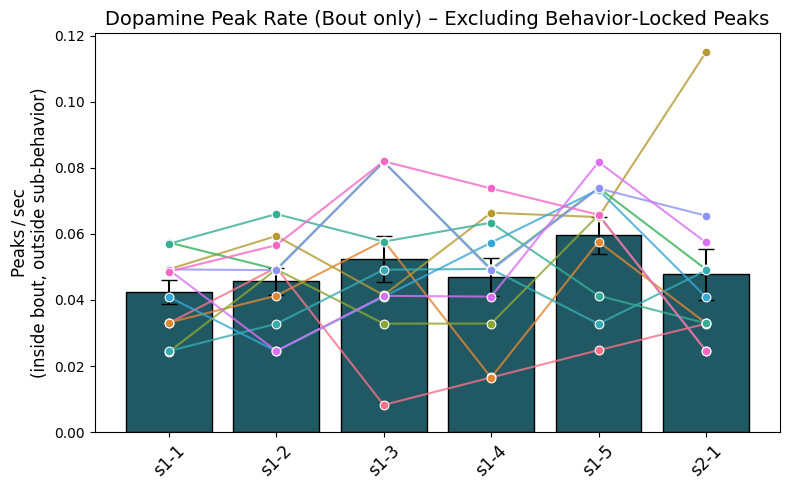

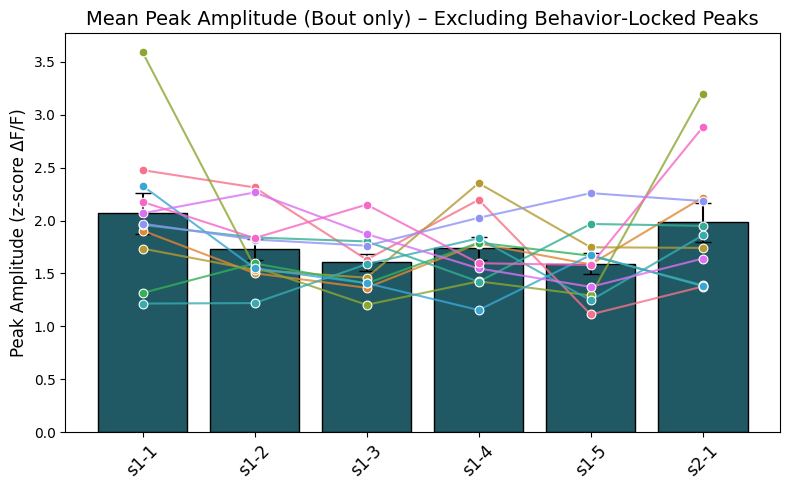

In [30]:
from collections import defaultdict

# Now exp_da_dict is a dict:  { subject_id: DataFrame_of_events_and_metrics, … }
exp_da_dict = get_trial_dataframes(experiment)

# ───── 2) Build `bout_bounds_df` (each row = one bout’s [Subject,Bout,Start,End]) ──
bout_bounds_df = experiment.get_bout_boundaries_df(bout_definitions)

# Example columns: ['Subject', 'Bout', 'Bout_Start_s', 'Bout_End_s']
# Print the first few lines to verify:
print("=== bout_bounds_df ===\n", bout_bounds_df.head(), "\n")

# ───── 3) Build a complete “behavior_df” that lists every (Subject,Bout,Event_Start,Event_End) ──
# Each trial in `experiment.trials` has a .behaviors DataFrame (with columns [Behavior, Event_Start, Event_End, Bout]).
# We will concatenate them all into one big DataFrame called behavior_df.

behavior_rows = []
for trial_name, trial in experiment.trials.items():
    subj = trial.subject_name
    dfb = trial.behaviors
    if dfb is None or dfb.empty:
        continue

    # Each row of dfb already has 'Behavior', 'Event_Start', 'Event_End', 'Bout'
    for idx, row in dfb.iterrows():
        behavior_rows.append({
            'Subject'    : subj,
            'Bout'       : row['Bout'],
            'Behavior'   : row['Behavior'],
            'Event_Start': float(row['Event_Start']),
            'Event_End'  : float(row['Event_End'])
        })

behavior_df = pd.DataFrame(behavior_rows)
print("=== behavior_df (first 5 rows) ===\n", behavior_df.head(), "\n")

# ───── 4) Detect spontaneous peaks in each trial’s z‐score trace ──────────────────
# We will reconstruct exactly the same logic you used (MAD threshold, min distance, min width).
def detect_spontaneous_events(
    timestamps: np.ndarray,
    signal: np.ndarray,
    threshold_factor: float = 3.0,
    min_distance_s: float = 1.0,
    min_width_s:    float = 0.5
):
    """
    (Exactly as before)
    Returns:
      peak_times (np.ndarray),
      peak_amps  (np.ndarray),
      peak_widths(np.ndarray, in seconds)
    """
    med = np.median(signal)
    mad = np.median(np.abs(signal - med))
    thresh = med + threshold_factor * mad

    dt = np.median(np.diff(timestamps))
    min_dist_samples  = int(np.round(min_distance_s / dt))
    min_width_samples = int(np.round(min_width_s    / dt))

    peaks, props = find_peaks(
        signal,
        height=thresh,
        distance=min_dist_samples,
        width=min_width_samples
    )

    peak_times  = timestamps[peaks]
    peak_amps   = signal[peaks]
    peak_widths = props["widths"] * dt

    return peak_times, peak_amps, peak_widths


def build_event_dataframe(
    experiment,
    threshold_factor: float = 3.0,
    min_distance_s:    float = 1.0,
    min_width_s:       float = 0.5
) -> pd.DataFrame:
    """
    Loops through experiment.trials, runs detect_spontaneous_events on each trial,
    and returns a DataFrame with columns:
      Subject | Trial | Event_Time | Amplitude | Width_s
    """
    rows = []
    for trial_name, trial in experiment.trials.items():
        subj = trial.subject_name
        ts   = np.array(trial.timestamps)
        sig  = np.array(trial.zscore)

        peak_times, peak_amps, peak_widths = detect_spontaneous_events(
            ts, sig,
            threshold_factor=threshold_factor,
            min_distance_s=min_distance_s,
            min_width_s=min_width_s
        )

        for t, a, w in zip(peak_times, peak_amps, peak_widths):
            rows.append({
                "Subject"   : subj,
                "Trial"     : trial_name,
                "Event_Time": float(t),
                "Amplitude" : float(a),
                "Width_s"   : float(w)
            })

    return pd.DataFrame(rows)


peaks_df = build_event_dataframe(
    experiment,
    threshold_factor=2.0,   # ← use 2×MAD (or 2.5, whatever you used previously)
    min_distance_s=0.5,
    min_width_s=0.3
)

# Show a few rows
print("=== peaks_df (first 5 rows) ===\n", peaks_df.head(), "\n")

# ───── 5) “Filter out” any peak that falls inside a sub‐behavioral event ─────────
# We want to keep only those peaks that lie inside [Bout_Start, Bout_End]
# but do NOT lie inside any [Event_Start, Event_End] from behavior_df.

# 5a) Pre‐group all behavior intervals by (Subject, Bout) for quick lookup
sub_behavior_intervals = defaultdict(list)
for idx, row in behavior_df.iterrows():
    key = (row['Subject'], row['Bout'])
    sub_behavior_intervals[key].append((row['Event_Start'], row['Event_End']))

# 5b) For each peak in peaks_df, ask:  “Which (Subject,Bout) does this peak belong to?”
#      Then check if that peak_time ∈ any of the sub‐behavior intervals for that (Subject,Bout).
keep_mask = np.zeros(len(peaks_df), dtype=bool)

# Convert some columns to numpy arrays for speed:
peak_subjects = peaks_df['Subject'].to_numpy()
peak_times    = peaks_df['Event_Time'].to_numpy()

bout_subs    = bout_bounds_df['Subject'].to_numpy()
bout_labels  = bout_bounds_df['Bout'].to_numpy()
bout_starts  = bout_bounds_df['Bout_Start_s'].to_numpy()
bout_ends    = bout_bounds_df['Bout_End_s'].to_numpy()

for i in range(len(peaks_df)):
    subj = peak_subjects[i]
    t    = peak_times[i]

    # 5b-i) Pull all rows of bout_bounds_df for this subject:
    subj_rows = np.where(bout_subs == subj)[0]

    # If the subject has no bouts at all, skip
    if len(subj_rows) == 0:
        continue

    kept_this_peak = False
    for j in subj_rows:
        b0 = float(bout_starts[j])
        b1 = float(bout_ends[j])
        lbl = bout_labels[j]  # e.g. 's1-3'

        # Does t lie in [b0,b1]?
        if (t >= b0) and (t <= b1):
            # 5b-ii) Check if it also lies inside any (Event_Start→Event_End) for that (subj,lbl)
            drop_for_behavior = False
            for (e0, e1) in sub_behavior_intervals[(subj, lbl)]:
                if (t >= e0) and (t <= e1):
                    drop_for_behavior = True
                    break

            if not drop_for_behavior:
                kept_this_peak = True

            # Once we find the first bout that contains t, we can break:
            # a single peak cannot belong to >1 bout for the same subject
            break

    keep_mask[i] = kept_this_peak

# 5c) Slice peaks_df so that we only keep the “in‐bout, outside any sub‐behavior” peaks
filtered_peaks = peaks_df[keep_mask].copy()
print("Number of total peaks:", len(peaks_df))
print("Number of peaks after filtering out behavior‐locked:", len(filtered_peaks), "\n")

# filtered_peaks now has columns ['Subject','Trial','Event_Time','Amplitude','Width_s'] 
# and contains exactly those peaks that are inside a bout window but do NOT fall into any
# Investigation interval (or any other 'Behavior') that was annotated.

# ───── 6) Compute “peak‐rate (peaks/sec)” and “mean peak amplitude” per subject × bout ──

bouts_list = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']
subjects_list = sorted(peaks_df['Subject'].unique())

# 6a) Compute peak‐rate = (# filtered_peaks in bout) / (bout duration)
rate_dict = {bout: {} for bout in bouts_list}

for subj in subjects_list:
    subp = filtered_peaks[ filtered_peaks['Subject'] == subj ]
    # Grab only that subject’s bouts
    subj_bb = bout_bounds_df[ bout_bounds_df['Subject'] == subj ]
    for bout in bouts_list:
        row = subj_bb[subj_bb['Bout'] == bout]
        if row.empty:
            rate_dict[bout][subj] = np.nan
            continue

        b0 = float(row['Bout_Start_s'].iloc[0])
        b1 = float(row['Bout_End_s'].iloc[0])
        dur_s = b1 - b0
        if dur_s <= 0:
            rate_dict[bout][subj] = np.nan
            continue

        count_peaks = np.sum((subp['Event_Time'] >= b0) & (subp['Event_Time'] <= b1))
        rate_dict[bout][subj] = count_peaks / dur_s  # peaks per second

rate_df = pd.DataFrame(rate_dict).T  # index=bout, columns=subject
rate_df = rate_df[subjects_list]     # ensure consistent column order

# 6b) Compute mean peak amplitude (on the same filtered peaks) per subject×bout
amp_dict = {bout: {} for bout in bouts_list}

for subj in subjects_list:
    subp = filtered_peaks[ filtered_peaks['Subject'] == subj ]
    subj_bb = bout_bounds_df[ bout_bounds_df['Subject'] == subj ]
    for bout in bouts_list:
        row = subj_bb[subj_bb['Bout'] == bout]
        if row.empty:
            amp_dict[bout][subj] = np.nan
            continue

        b0 = float(row['Bout_Start_s'].iloc[0])
        b1 = float(row['Bout_End_s'].iloc[0])
        # Pick out the amplitudes of filtered_peaks that lie in [b0,b1]
        mask = (subp['Event_Time'] >= b0) & (subp['Event_Time'] <= b1)
        vals = subp.loc[mask, 'Amplitude'].to_numpy()
        if len(vals) == 0:
            amp_dict[bout][subj] = np.nan
        else:
            amp_dict[bout][subj] = np.nanmean(vals)

amp_df = pd.DataFrame(amp_dict).T  # index=bout, columns=subject
amp_df = amp_df[subjects_list]

# ───── 7) Plot “Peak Rate (peaks/sec)” in each Bout (excluding behavior‐locked peaks) ─────
plt.figure(figsize=(8,5))
x     = np.arange(len(bouts_list))
bar_w = 0.6

# 7a) Group mean ± SEM (across subjects) for each bout
rate_means = rate_df.mean(axis=1)
rate_sems  = rate_df.sem(axis=1)

sns.barplot(
    x=bouts_list, y=rate_means.values,
    yerr=rate_sems.values,
    color=brain_region,
    edgecolor='black',
    capsize=0.1
)
plt.errorbar(
    x, rate_means.values,
    yerr=rate_sems.values,
    fmt='none',
    ecolor='black',
    capsize=6,
    linewidth=1.2
)

# 7b) Overlay one colored line + dot per subject
palette = sns.color_palette("husl", len(subjects_list))
subject_colors = dict(zip(subjects_list, palette))

for idx, subj in enumerate(subjects_list):
    y = rate_df.loc[:, subj].values
    plt.plot(
        x, y,
        '-', color=subject_colors[subj],
        linewidth=1.5, alpha=0.8
    )
    plt.scatter(
        x, y,
        color=subject_colors[subj],
        s=40,
        edgecolor='white',
        linewidth=0.8,
        zorder=5
    )

plt.xticks(x, bouts_list, rotation=45, fontsize=12)
plt.ylabel('Peaks / sec\n(inside bout, outside sub‐behavior)', fontsize=12)
plt.title('Dopamine Peak Rate (Bout only) – Excluding Behavior‐Locked Peaks', fontsize=14)
plt.tight_layout()
plt.show()


# ───── 8) Plot “Mean Peak Amplitude” in each Bout (excluding behavior‐locked peaks) ─────
plt.figure(figsize=(8,5))
x     = np.arange(len(bouts_list))
bar_w = 0.6

# 8a) Group mean ± SEM for each bout
amp_means = amp_df.mean(axis=1)
amp_sems  = amp_df.sem(axis=1)

sns.barplot(
    x=bouts_list, y=amp_means.values,
    yerr=amp_sems.values,
    color=brain_region,
    edgecolor='black',
    capsize=0.1
)
plt.errorbar(
    x, amp_means.values,
    yerr=amp_sems.values,
    fmt='none',
    ecolor='black',
    capsize=6,
    linewidth=1.2
)

# 8b) Overlay one colored line + dot per subject
for idx, subj in enumerate(subjects_list):
    y = amp_df.loc[:, subj].values
    plt.plot(
        x, y,
        '-', color=subject_colors[subj],
        linewidth=1.5, alpha=0.8
    )
    plt.scatter(
        x, y,
        color=subject_colors[subj],
        s=40,
        edgecolor='white',
        linewidth=0.8,
        zorder=5
    )

plt.xticks(x, bouts_list, rotation=45, fontsize=12)
plt.ylabel('Peak Amplitude (z‐score ΔF/F)', fontsize=12)
plt.title('Mean Peak Amplitude (Bout only) – Excluding Behavior‐Locked Peaks', fontsize=14)
plt.tight_layout()
plt.show()


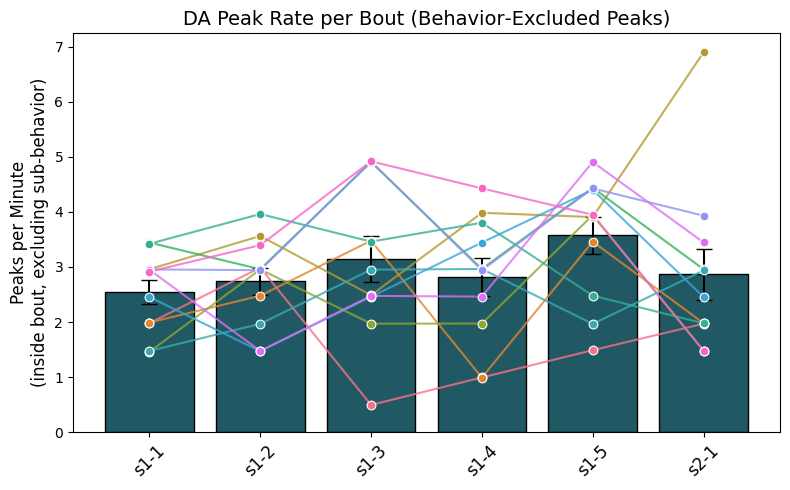

In [31]:
# ───── 1) Compute and plot “Peak Rate (peaks/min)” per Bout ─────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.signal import find_peaks

# (Assumes `experiment` has already been processed as in the previous block:
#   default_batch_process(), group_extract_manual_annotations(...), compute_all_da_metrics(...))

# 1a) Build `bout_bounds_df` (one row per Subject × Bout with start/end times)
bout_definitions = [
    {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
    {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'}
]
bout_bounds_df = experiment.get_bout_boundaries_df(bout_definitions)

# 1b) Build a DataFrame of all spontaneous peaks
def detect_spontaneous_events(timestamps, signal,
                              threshold_factor=2.0,
                              min_distance_s=0.5,
                              min_width_s=0.3):
    med = np.median(signal)
    mad = np.median(np.abs(signal - med))
    thresh = med + threshold_factor * mad

    dt = np.median(np.diff(timestamps))
    min_dist_samples  = int(np.round(min_distance_s / dt))
    min_width_samples = int(np.round(min_width_s    / dt))

    peaks, props = find_peaks(
        signal,
        height=thresh,
        distance=min_dist_samples,
        width=min_width_samples
    )
    peak_times  = timestamps[peaks]
    peak_amps   = signal[peaks]
    peak_widths = props["widths"] * dt
    return peak_times, peak_amps, peak_widths

def build_event_dataframe(experiment,
                          threshold_factor=2.0,
                          min_distance_s=0.5,
                          min_width_s=0.3):
    rows = []
    for trial_name, trial in experiment.trials.items():
        subj = trial.subject_name
        ts   = np.array(trial.timestamps)
        sig  = np.array(trial.zscore)
        peak_times, peak_amps, peak_widths = detect_spontaneous_events(
            ts, sig,
            threshold_factor=threshold_factor,
            min_distance_s=min_distance_s,
            min_width_s=min_width_s
        )
        for t, a, w in zip(peak_times, peak_amps, peak_widths):
            rows.append({
                "Subject"   : subj,
                "Trial"     : trial_name,
                "Event_Time": float(t),
                "Amplitude" : float(a),
                "Width_s"   : float(w)
            })
    return pd.DataFrame(rows)

peaks_df = build_event_dataframe(experiment)

# 1c) Build a dictionary of all behavior intervals (to exclude behavior‐locked peaks)
behavior_rows = []
for trial_name, trial in experiment.trials.items():
    subj = trial.subject_name
    dfb = trial.behaviors
    if dfb is None or dfb.empty:
        continue
    for _, row in dfb.iterrows():
        behavior_rows.append({
            'Subject'    : subj,
            'Bout'       : row['Bout'],
            'Event_Start': float(row['Event_Start']),
            'Event_End'  : float(row['Event_End'])
        })
behavior_df = pd.DataFrame(behavior_rows)

sub_behavior_intervals = defaultdict(list)
for _, row in behavior_df.iterrows():
    key = (row['Subject'], row['Bout'])
    sub_behavior_intervals[key].append((row['Event_Start'], row['Event_End']))

# 1d) Filter out any peak that falls inside a behavior interval
keep_mask = np.zeros(len(peaks_df), dtype=bool)
peak_subjects = peaks_df['Subject'].to_numpy()
peak_times    = peaks_df['Event_Time'].to_numpy()

bout_subs   = bout_bounds_df['Subject'].to_numpy()
bout_labels = bout_bounds_df['Bout'].to_numpy()
bout_starts = bout_bounds_df['Bout_Start_s'].to_numpy()
bout_ends   = bout_bounds_df['Bout_End_s'].to_numpy()

for i in range(len(peaks_df)):
    subj = peak_subjects[i]
    t    = peak_times[i]
    subj_rows = np.where(bout_subs == subj)[0]
    if len(subj_rows) == 0:
        continue
    kept_this_peak = False
    for j in subj_rows:
        b0  = float(bout_starts[j])
        b1  = float(bout_ends[j])
        lbl = bout_labels[j]
        if (t >= b0) and (t <= b1):
            drop_for_behavior = False
            for (e0, e1) in sub_behavior_intervals[(subj, lbl)]:
                if (t >= e0) and (t <= e1):
                    drop_for_behavior = True
                    break
            if not drop_for_behavior:
                kept_this_peak = True
            break
    keep_mask[i] = kept_this_peak

filtered_peaks = peaks_df[keep_mask].copy()

# 1e) Compute “peaks per minute” for each Subject × Bout
bouts_list = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']
subjects_list = sorted(peaks_df['Subject'].unique())

rate_dict = {bout: {} for bout in bouts_list}
for subj in subjects_list:
    subp = filtered_peaks[filtered_peaks['Subject'] == subj]
    subj_bb = bout_bounds_df[bout_bounds_df['Subject'] == subj]
    for bout in bouts_list:
        row = subj_bb[subj_bb['Bout'] == bout]
        if row.empty:
            rate_dict[bout][subj] = np.nan
            continue
        b0 = float(row['Bout_Start_s'].iloc[0])
        b1 = float(row['Bout_End_s'].iloc[0])
        dur_s = b1 - b0
        if dur_s <= 0:
            rate_dict[bout][subj] = np.nan
            continue
        count_peaks = np.sum((subp['Event_Time'] >= b0) & (subp['Event_Time'] <= b1))
        # peaks per minute = count / (duration in minutes)
        rate_dict[bout][subj] = count_peaks / (dur_s / 60.0)

rate_df = pd.DataFrame(rate_dict).T  # index=bout, columns=subject
rate_df = rate_df[subjects_list]

# 1f) Plot “Peaks per Minute” in each Bout
plt.figure(figsize=(8, 5))
x     = np.arange(len(bouts_list))
bar_w = 0.6

rate_means = rate_df.mean(axis=1)
rate_sems  = rate_df.sem(axis=1)

sns.barplot(
    x=bouts_list, y=rate_means.values,
    yerr=rate_sems.values,
    color=brain_region,
    edgecolor='black',
    capsize=0.1
)
plt.errorbar(
    x, rate_means.values,
    yerr=rate_sems.values,
    fmt='none',
    ecolor='black',
    capsize=6,
    linewidth=1.2
)

palette = sns.color_palette("husl", len(subjects_list))
subject_colors = dict(zip(subjects_list, palette))

for subj in subjects_list:
    y = rate_df.loc[:, subj].values
    plt.plot(
        x, y,
        '-', color=subject_colors[subj],
        linewidth=1.5, alpha=0.8
    )
    plt.scatter(
        x, y,
        color=subject_colors[subj],
        s=40,
        edgecolor='white',
        linewidth=0.8,
        zorder=5
    )

plt.xticks(x, bouts_list, rotation=45, fontsize=12)
plt.ylabel('Peaks per Minute\n(inside bout, excluding sub‐behavior)', fontsize=12)
plt.title('DA Peak Rate per Bout (Behavior‐Excluded Peaks)', fontsize=14)
plt.tight_layout()
plt.show()


In [32]:
# # ───── Compute and plot “Peak Rate (peaks/min)” during Behavior Intervals ───────

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from collections import defaultdict
# from scipy.signal import find_peaks

# # (Assumes `experiment` has already been processed:
# #   default_batch_process(), group_extract_manual_annotations(...), compute_all_da_metrics(...))

# # 1) Build `bout_bounds_df` (one row per Subject × Bout with start/end times)
# bout_definitions = [
#     {'prefix': 's1', 'introduced': 's1_Introduced', 'removed': 's1_Removed'},
#     {'prefix': 's2', 'introduced': 's2_Introduced', 'removed': 's2_Removed'}
# ]
# bout_bounds_df = experiment.get_bout_boundaries_df(bout_definitions)

# # 2) Build a DataFrame of all spontaneous peaks (same as before)
# def detect_spontaneous_events(timestamps, signal,
#                               threshold_factor=2.0,
#                               min_distance_s=0.5,
#                               min_width_s=0.3):
#     med = np.median(signal)
#     mad = np.median(np.abs(signal - med))
#     thresh = med + threshold_factor * mad

#     dt = np.median(np.diff(timestamps))
#     min_dist_samples  = int(np.round(min_distance_s / dt))
#     min_width_samples = int(np.round(min_width_s    / dt))

#     peaks, props = find_peaks(
#         signal,
#         height=thresh,
#         distance=min_dist_samples,
#         width=min_width_samples
#     )
#     peak_times  = timestamps[peaks]
#     peak_amps   = signal[peaks]
#     peak_widths = props["widths"] * dt
#     return peak_times, peak_amps, peak_widths

# def build_event_dataframe(experiment,
#                           threshold_factor=2.0,
#                           min_distance_s=0.5,
#                           min_width_s=0.3):
#     rows = []
#     for trial_name, trial in experiment.trials.items():
#         subj = trial.subject_name
#         ts   = np.array(trial.timestamps)
#         sig  = np.array(trial.zscore)
#         peak_times, peak_amps, peak_widths = detect_spontaneous_events(
#             ts, sig,
#             threshold_factor=threshold_factor,
#             min_distance_s=min_distance_s,
#             min_width_s=min_width_s
#         )
#         for t, a, w in zip(peak_times, peak_amps, peak_widths):
#             rows.append({
#                 "Subject"   : subj,
#                 "Trial"     : trial_name,
#                 "Event_Time": float(t),
#                 "Amplitude" : float(a),
#                 "Width_s"   : float(w)
#             })
#     return pd.DataFrame(rows)

# peaks_df = build_event_dataframe(experiment)

# # 3) Build a dictionary of all behavior intervals
# behavior_rows = []
# for trial_name, trial in experiment.trials.items():
#     subj = trial.subject_name
#     dfb = trial.behaviors
#     if dfb is None or dfb.empty:
#         continue
#     for _, row in dfb.iterrows():
#         behavior_rows.append({
#             'Subject'    : subj,
#             'Bout'       : row['Bout'],
#             'Event_Start': float(row['Event_Start']),
#             'Event_End'  : float(row['Event_End'])
#         })
# behavior_df = pd.DataFrame(behavior_rows)

# # 4) Group behavior intervals by (Subject, Bout)
# sub_behavior_intervals = defaultdict(list)
# for _, row in behavior_df.iterrows():
#     key = (row['Subject'], row['Bout'])
#     sub_behavior_intervals[key].append((row['Event_Start'], row['Event_End']))

# # 5) Keep only peaks that fall inside any behavior interval
# keep_mask = np.zeros(len(peaks_df), dtype=bool)
# peak_subjects = peaks_df['Subject'].to_numpy()
# peak_times    = peaks_df['Event_Time'].to_numpy()

# bout_subs   = bout_bounds_df['Subject'].to_numpy()
# bout_labels = bout_bounds_df['Bout'].to_numpy()
# bout_starts = bout_bounds_df['Bout_Start_s'].to_numpy()
# bout_ends   = bout_bounds_df['Bout_End_s'].to_numpy()

# for i in range(len(peaks_df)):
#     subj = peak_subjects[i]
#     t    = peak_times[i]
#     subj_rows = np.where(bout_subs == subj)[0]
#     if len(subj_rows) == 0:
#         continue
#     kept_this_peak = False
#     for j in subj_rows:
#         b0  = float(bout_starts[j])
#         b1  = float(bout_ends[j])
#         lbl = bout_labels[j]
#         # Check if t is within the bout window first
#         if (t >= b0) and (t <= b1):
#             # Now check if it lies in any sub‐behavior interval
#             for (e0, e1) in sub_behavior_intervals[(subj, lbl)]:
#                 if (t >= e0) and (t <= e1):
#                     kept_this_peak = True
#                     break
#             break
#     keep_mask[i] = kept_this_peak

# behavior_peaks = peaks_df[keep_mask].copy()

# # 6) Compute “peaks per minute” for each Subject × Bout, but only counting peaks
# #    that fell inside behavior intervals. Total time = sum of behavior durations in that bout.
# bouts_list    = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']
# subjects_list = sorted(peaks_df['Subject'].unique())

# rate_dict_beh = {bout: {} for bout in bouts_list}
# for subj in subjects_list:
#     subp = behavior_peaks[behavior_peaks['Subject'] == subj]
#     subj_bb = bout_bounds_df[bout_bounds_df['Subject'] == subj]
#     for bout in bouts_list:
#         row = subj_bb[subj_bb['Bout'] == bout]
#         if row.empty:
#             rate_dict_beh[bout][subj] = np.nan
#             continue
#         # Sum durations of all behavior intervals in this bout
#         intervals = sub_behavior_intervals[(subj, bout)]
#         total_beh_time_s = sum((e1 - e0) for (e0, e1) in intervals)
#         if total_beh_time_s <= 0:
#             rate_dict_beh[bout][subj] = np.nan
#             continue
#         # Count peaks inside those behavior intervals
#         count_peaks = 0
#         for (e0, e1) in intervals:
#             count_peaks += np.sum((subp['Event_Time'] >= e0) & (subp['Event_Time'] <= e1))
#         # Peaks per minute within behavior = count / (total_beh_time_s / 60)
#         rate_dict_beh[bout][subj] = count_peaks / (total_beh_time_s / 60.0)

# rate_df_beh = pd.DataFrame(rate_dict_beh).T  # index=bout, columns=subject
# rate_df_beh = rate_df_beh[subjects_list]

# # 7) Plot “Peaks per Minute during Behavior” in each Bout
# plt.figure(figsize=(8, 5))
# x     = np.arange(len(bouts_list))
# bar_w = 0.6

# rate_means_beh = rate_df_beh.mean(axis=1)
# rate_sems_beh  = rate_df_beh.sem(axis=1)

# sns.barplot(
#     x=bouts_list, y=rate_means_beh.values,
#     yerr=rate_sems_beh.values,
#     color=brain_region,
#     edgecolor='black',
#     capsize=0.1
# )
# plt.errorbar(
#     x, rate_means_beh.values,
#     yerr=rate_sems_beh.values,
#     fmt='none',
#     ecolor='black',
#     capsize=6,
#     linewidth=1.2
# )

# palette = sns.color_palette("husl", len(subjects_list))
# subject_colors = dict(zip(subjects_list, palette))

# for subj in subjects_list:
#     y = rate_df_beh.loc[:, subj].values
#     plt.plot(
#         x, y,
#         '-', color=subject_colors[subj],
#         linewidth=1.5, alpha=0.8
#     )
#     plt.scatter(
#         x, y,
#         color=subject_colors[subj],
#         s=40,
#         edgecolor='white',
#         linewidth=0.8,
#         zorder=5
#     )

# plt.xticks(x, bouts_list, rotation=45, fontsize=12)
# plt.ylabel('Peaks per Minute\n(during behavior only)', fontsize=12)
# plt.title('DA Peak Rate per Bout (Behavior‐Only)', fontsize=14)
# plt.tight_layout()
# plt.show()


In [33]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ── PARAMETERS ──────────────────────────────────────────────────────────────
# bouts           = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']
# entry_before    = 3.6   # seconds before bout start
# entry_after     = 1.0   # seconds after bout start
# subjects        = peaks_df['Subject'].unique()

# # ── 1) filter peaks after initial cutoff ─────────────────────────────────────
# peaks_cut = peaks_df[peaks_df['Event_Time'] >= 30]  # drop first 30 s

# # ── 2) compute mean peak amplitude in the entry window around bout start ────
# amps = {bout: {} for bout in bouts}

# for subj in subjects:
#     subp = peaks_cut[peaks_cut['Subject'] == subj]
#     for bout in bouts:
#         # get bout start for this subject & bout
#         bb = bout_bounds_df[
#             (bout_bounds_df['Subject'] == subj) &
#             (bout_bounds_df['Bout']    == bout)
#         ]
#         vals = []
#         for _, row in bb.iterrows():
#             start = row['Bout_Start_s']
#             # select peaks in [start - before, start + after]
#             window_mask = (
#                 (subp['Event_Time'] >= start - entry_before) &
#                 (subp['Event_Time'] <= start + entry_after)
#             )
#             vals.extend(subp.loc[window_mask, 'Amplitude'].tolist())
#         # mean amplitude (NaN if no peaks)
#         amps[bout][subj] = np.nanmean(vals) if vals else np.nan

# # ── 3) build DataFrame ──────────────────────────────────────────────────────
# amp_df = pd.DataFrame(amps)  # rows=subjects, cols=bouts

# # ── 4) compute group mean ± SEM ──────────────────────────────────────────────
# means = amp_df.mean(axis=0)
# sems  = amp_df.sem(axis=0)

# # ── 5) choose colors for each subject ────────────────────────────────────────
# palette = sns.color_palette("husl", len(subjects))
# subject_colors = dict(zip(subjects, palette))

# # ── 6) plot ─────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8,5))
# x     = np.arange(len(bouts))
# bar_w = 0.6

# # grey bars = group mean ± SEM
# ax.bar(
#     x, means,
#     yerr=sems,
#     capsize=6,
#     width=bar_w,
#     color='lightgray',
#     edgecolor='black',
#     linewidth=1.5
# )

# # one line + dot per mouse
# for subj in subjects:
#     y = amp_df.loc[subj, bouts].values
#     ax.plot(
#         x, y,
#         '-',
#         color=subject_colors[subj],
#         linewidth=1.5, alpha=0.8
#     )
#     ax.scatter(
#         x, y,
#         color=subject_colors[subj],
#         s=50,
#         edgecolor='white',
#         linewidth=0.8,
#         zorder=5
#     )

# # cosmetics
# ax.set_xticks(x)
# ax.set_xticklabels(bouts, rotation=45, fontsize=12)
# ax.set_ylabel('Peak Amplitude (z-score ΔF/F)', fontsize=12)
# ax.set_title('Mean Peak Amplitude during Entry Windows\n(–3.6 s → +1 s)', fontsize=14)
# plt.tight_layout()
# plt.show()


In [34]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1) define your ordered bouts
# bouts = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']

# # 2) restrict peaks to after the 30 s cut
# peaks = peaks_df[peaks_df.Event_Time >= 30].copy()

# # 3) get bout boundaries
# bb = bout_bounds_df.copy()
# # we assume bb has columns ['Subject','Bout','Bout_Start_s','Bout_End_s']

# # 4) build entry‐rates: peaks/sec in [Bout_Start, Bout_End]
# entry_rates = {bout: {} for bout in bouts}
# for subj in peaks.Subject.unique():
#     subp = peaks[peaks.Subject==subj]
#     for bout in bouts:
#         row = bb[(bb.Subject==subj)&(bb.Bout==bout)]
#         if row.empty:
#             entry_rates[bout][subj] = np.nan
#             continue
#         t0, t1 = row.iloc[0][['Bout_Start_s','Bout_End_s']]
#         dur = t1 - t0
#         if dur<=0:
#             entry_rates[bout][subj] = np.nan
#         else:
#             cnt = ((subp.Event_Time>=t0)&(subp.Event_Time<=t1)).sum()
#             entry_rates[bout][subj] = cnt/dur

# entry_df = pd.DataFrame(entry_rates).T  # index=bouts, cols=subjects

# # 5) build removal‐rates: from Bout_End until next Bout_Start (or trial end)
# removal_rates = {bout: {} for bout in bouts}
# # first gather trial durations
# trial_durs = {trial_name: 
#                experiment.trials[trial_name].timestamps[-1]
#                for trial_name in experiment.trials}

# for subj in peaks.Subject.unique():
#     # get this subject's ordered boundaries
#     subj_bb = bb[bb.Subject==subj].set_index('Bout').loc[bouts]
#     # find the trial name for this subject (we assume one trial per subj)
#     trial_name = next(t for t,tr in experiment.trials.items() if tr.subject_name==subj)
#     rec_end = trial_durs[trial_name]
#     for i,bout in enumerate(bouts):
#         t1 = subj_bb.loc[bout,'Bout_End_s']
#         # next introduction time or recording end
#         if i+1<len(bouts):
#             t2 = subj_bb.loc[bouts[i+1],'Bout_Start_s']
#         else:
#             t2 = rec_end
#         dur = t2 - t1
#         if dur<=0:
#             removal_rates[bout][subj] = np.nan
#         else:
#             cnt = ((peaks.Subject==subj)&
#                    (peaks.Event_Time>=t1)&
#                    (peaks.Event_Time<=t2)).sum()
#             removal_rates[bout][subj] = cnt/dur

# removal_df = pd.DataFrame(removal_rates).T  # index=bouts, cols=subjects

# # 6) pick colors
# subjects = entry_df.columns.tolist()
# cmap = plt.cm.get_cmap('tab20', len(subjects))
# colormap = {s: cmap(i) for i,s in enumerate(subjects)}

# # 7) plot entry rates
# fig,ax = plt.subplots(figsize=(8,4))
# x = np.arange(len(bouts))
# bar_w = 0.6

# # gray bars = group mean
# means = entry_df.mean(axis=1)
# ax.bar(x, means, width=bar_w, color='lightgray', edgecolor='k')

# # lines + dots per subject
# for subj in subjects:
#     y = entry_df[subj].values
#     ax.plot(x, y, '-', color=colormap[subj], lw=2.5, alpha=0.8)
#     ax.scatter(x, y, color=colormap[subj], s=60, edgecolor='k', zorder=4)

# ax.set_xticks(x)
# ax.set_xticklabels(bouts, rotation=45)
# ax.set_ylabel('Peaks/sec (entry)')
# ax.set_title('Dopamine Peak Rate during Entry Bouts')
# plt.tight_layout()


# # 8) plot removal rates
# fig,ax = plt.subplots(figsize=(8,4))
# means = removal_df.mean(axis=1)
# ax.bar(x, means, width=bar_w, color='lightgray', edgecolor='k')

# for subj in subjects:
#     y = removal_df[subj].values
#     ax.plot(x, y, '-', color=colormap[subj], lw=2.5, alpha=0.8)
#     ax.scatter(x, y, color=colormap[subj], s=60, edgecolor='k', zorder=4)

# ax.set_xticks(x)
# ax.set_xticklabels(bouts, rotation=45)
# ax.set_ylabel('Peaks/sec (removal)')
# ax.set_title('Dopamine Peak Rate during Removal Intervals')
# plt.tight_layout()

# plt.show()


/var/folders/tj/nfn3dynx2n19r7566d88xmsc0000gn/T/ipykernel_68856/3120622893.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(subjects))


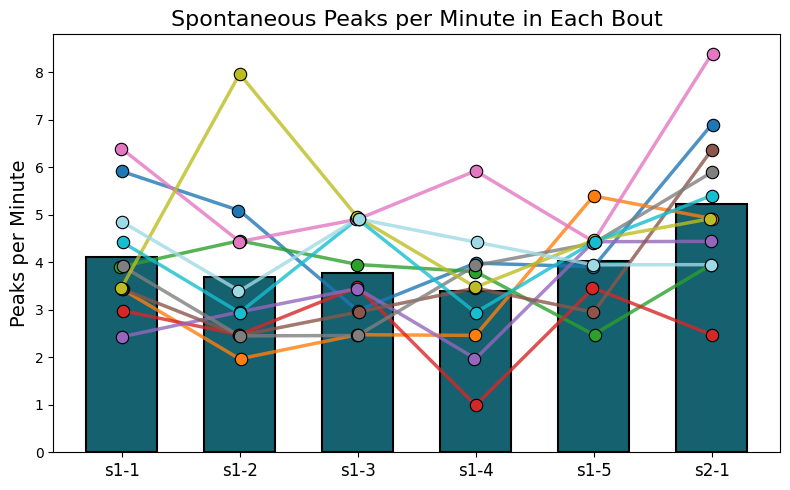

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Define which bouts to include, in order
bouts = ['s1-1', 's1-2', 's1-3', 's1-4', 's1-5', 's2-1']

# --- 2) Drop the first 30 s and restrict to your peaks
peaks_df = peaks_df[peaks_df.Event_Time >= 30]

# --- 3) Build a table of peaks-per-minute per bout per subject
subjects = peaks_df['Subject'].unique()
rates = {bout: {} for bout in bouts}

for subj in subjects:
    subp = peaks_df[peaks_df.Subject == subj]
    for bout in bouts:
        # grab that subject’s bout window(s)
        bb = bout_bounds_df[
            (bout_bounds_df.Subject == subj) &
            (bout_bounds_df.Bout    == bout)
        ]
        # there should normally be one row per bout:
        total_peaks = 0
        total_time_s = 0
        for _, row in bb.iterrows():
            t0 = row.Bout_Start_s
            t1 = row.Bout_End_s
            total_peaks   += ((subp.Event_Time >= t0) & (subp.Event_Time <= t1)).sum()
            total_time_s  += (t1 - t0)
        # convert to “per minute”
        if total_time_s > 0:
            rates[bout][subj] = total_peaks / (total_time_s / 60)
        else:
            rates[bout][subj] = 0.0

# rows=bouts, cols=subjects
rate_df = pd.DataFrame(rates).T  # shape (6, n_subjects)

# --- 4) Compute the group‐mean rate for each bout
mean_rate = rate_df.mean(axis=1)

# --- 5) Pick one color per mouse
cmap = plt.cm.get_cmap("tab20", len(subjects))
subject_colors = {s: cmap(i) for i, s in enumerate(subjects)}

# --- 6) Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(bouts))
bar_width = 0.6

# a) light‐gray bars = mean peaks/min
ax.bar(x, mean_rate, width=bar_width,
       color=brain_region, edgecolor="k", linewidth=1.5)

# b) connect each mouse’s rate across bouts
for subj in subjects:
    y = rate_df[subj].values
    ax.plot(x, y, '-', color=subject_colors[subj],
            lw=2.5, alpha=0.8, zorder=3)

# c) overlay each mouse’s dot
for i, bout in enumerate(bouts):
    for subj in subjects:
        y = rate_df.loc[bout, subj]
        jitter = np.random.uniform(-bar_width*0.02, bar_width*0.02)
        ax.scatter(i + jitter, y,
                   color=subject_colors[subj],
                   s=80, edgecolor="k", linewidth=0.8,
                   zorder=4, label=subj)

# d) clean up legend (one entry per subject)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(),
#           title="Subject", bbox_to_anchor=(1.02,1),
#           loc="upper left", frameon=False)

# e) axis labels & title
ax.set_xticks(x)
ax.set_xticklabels(bouts, fontsize=12)
ax.set_ylabel("Peaks per Minute", fontsize=14)
ax.set_title("Spontaneous Peaks per Minute in Each Bout", fontsize=16)
plt.tight_layout()
plt.show()
# Average amplitude per bout

/var/folders/tj/nfn3dynx2n19r7566d88xmsc0000gn/T/ipykernel_68856/1907923998.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(subjects))


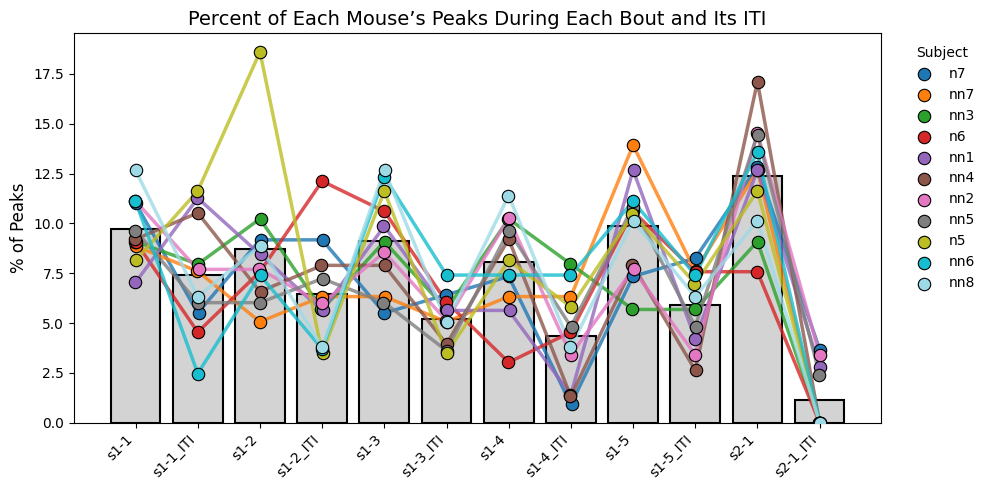

In [36]:
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) define your ordered bouts
bouts = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']

# 2) build list of segment labels in order: bout, bout_ITI, bout2, bout2_ITI, ...
segments = []
for b in bouts:
    segments.append(b)
    segments.append(f"{b}_ITI")

# 3) filter peaks after the 30 s cut
peaks_df = peaks_df[peaks_df.Event_Time >= 30].copy()
subjects = peaks_df.Subject.unique()

# 4) initialize a dict of dicts: pct[segment][subject]
pct = {seg: {} for seg in segments}

# 5) for each subject, compute
for subj in subjects:
    subp = peaks_df[peaks_df.Subject==subj]
    total_peaks = len(subp)
    # get that subj's ordered bout boundaries
    sb = bout_bounds_df[bout_bounds_df.Subject==subj].copy()
    sb = sb.set_index('Bout').loc[bouts]  # ensure same order
    
    # also find recording end
    tr = experiment.trials[next(iter(experiment.trials))]  # any trial
    rec_end = tr.timestamps[-1]
    
    # loop through bouts
    for i, bout in enumerate(bouts):
        # bout window
        start = sb.loc[bout,'Bout_Start_s']
        end   = sb.loc[bout,'Bout_End_s']
        cnt   = ((subp.Event_Time>=start)&(subp.Event_Time<=end)).sum()
        pct[bout][subj] = cnt/total_peaks*100 if total_peaks else 0
        
        # now ITI window: from this bout's end to next bout's start (or rec_end)
        next_start = (sb.loc[bouts[i+1],'Bout_Start_s']
                      if i+1 < len(bouts) else rec_end)
        # exclude the instant before next_start
        mask = (subp.Event_Time> end) & (subp.Event_Time< next_start)
        cnt2 = mask.sum()
        pct[f"{bout}_ITI"][subj] = cnt2/total_peaks*100 if total_peaks else 0

# 6) make DataFrame: rows=segments, cols=subjects
count_df = pd.DataFrame(pct).T.loc[segments]

# 7) compute group means
mean_pct = count_df.mean(axis=1)

# 8) pick distinct colors for mice
cmap = plt.cm.get_cmap("tab20", len(subjects))
subject_colors = {subj: cmap(i) for i, subj in enumerate(subjects)}

# 9) plot
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(segments))
bar_w = 0.8

# a) grey bars = group means
ax.bar(x, mean_pct, width=bar_w,
       color="lightgray", edgecolor="black", lw=1.5)

# b) lines per mouse
for subj in subjects:
    ys = count_df[subj].values
    ax.plot(x, ys, color=subject_colors[subj], lw=2.5, alpha=0.8, zorder=3)

# c) dots per mouse
for i, seg in enumerate(segments):
    for subj in subjects:
        y = count_df.loc[seg, subj]
        jitter = np.random.uniform(-bar_w*0.02, bar_w*0.02)
        ax.scatter(i + jitter, y,
                   color=subject_colors[subj],
                   s=80, edgecolor="black", lw=0.8,
                   zorder=4, label=subj)

# d) legend with one entry per mouse
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title="Subject", bbox_to_anchor=(1.02,1),
          loc="upper left", frameon=False)

# e) cosmetics
ax.set_xticks(x)
ax.set_xticklabels(segments, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("% of Peaks", fontsize=12)
ax.set_title("Percent of Each Mouse’s Peaks During Each Bout and Its ITI", fontsize=14)
plt.tight_layout()
plt.show()


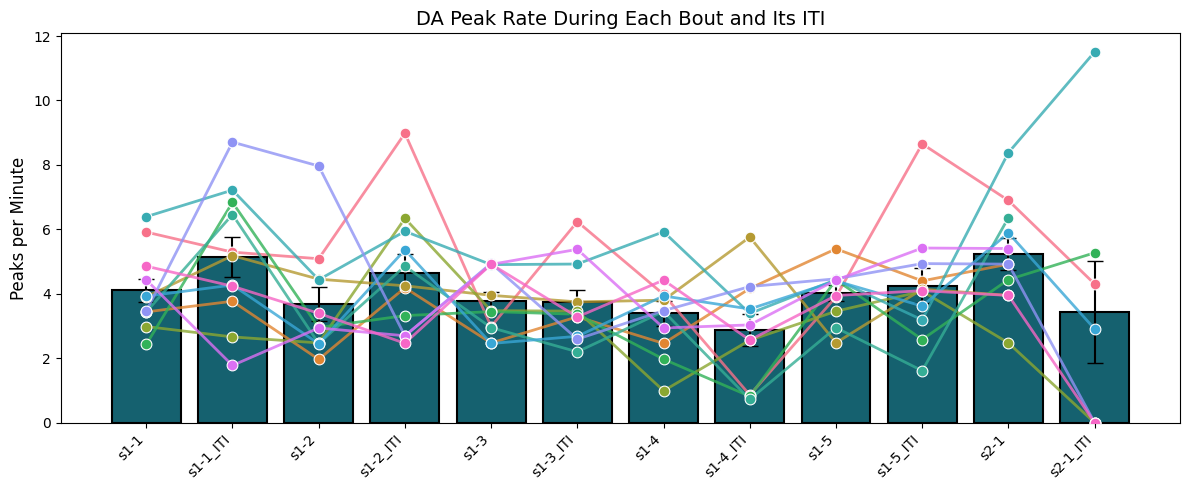

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) define your ordered bouts
bouts = ['s1-1','s1-2','s1-3','s1-4','s1-5','s2-1']

# 2) build list of segment labels in order: bout, bout_ITI, bout2, bout2_ITI, ...
segments = []
for b in bouts:
    segments.append(b)
    segments.append(f"{b}_ITI")

# 3) filter peaks after the 30 s cut
peaks_cut = peaks_df[peaks_df.Event_Time >= 30].copy()
subjects  = peaks_cut.Subject.unique()

# 4) initialize a dict of dicts: rates[segment][subject]
rates = {seg: {} for seg in segments}

# 5) for each subject, compute peaks/min for each segment
for subj in subjects:
    subp = peaks_cut[peaks_cut.Subject == subj]
    # get this subj’s bouts in the correct order
    sb = bout_bounds_df[bout_bounds_df.Subject == subj].set_index('Bout').loc[bouts]
    # find end of recording to cap the last ITI
    any_trial = next(iter(experiment.trials.values()))
    rec_end   = any_trial.timestamps[-1]

    for i, bout in enumerate(bouts):
        # —— BOUT itself
        start = sb.loc[bout, 'Bout_Start_s']
        end   = sb.loc[bout, 'Bout_End_s']
        dur_s = end - start
        cnt   = ((subp.Event_Time >= start) & (subp.Event_Time <= end)).sum()
        # convert to per‐minute
        rates[bout][subj] = (cnt / dur_s * 60) if dur_s > 0 else np.nan

        # —— ITI: from this bout’s end to next bout’s start (or rec_end)
        next_start = sb.loc[bouts[i+1], 'Bout_Start_s'] if i+1 < len(bouts) else rec_end
        dur_iti    = next_start - end
        cnt_iti    = ((subp.Event_Time > end) & (subp.Event_Time < next_start)).sum()
        rates[f"{bout}_ITI"][subj] = (cnt_iti / dur_iti * 60) if dur_iti > 0 else np.nan

# 6) build DataFrame: index=subjects, cols=segments
rates_df = pd.DataFrame(rates).T.loc[segments].T

# 7) compute group mean ± SEM for each segment
means = rates_df.mean(axis=0)
sems  = rates_df.sem(axis=0)

# 8) pick distinct colors per mouse
import seaborn as sns
palette = sns.color_palette("husl", len(subjects))
subject_colors = dict(zip(subjects, palette))

# 9) plot
fig, ax = plt.subplots(figsize=(12,5))
x     = np.arange(len(segments))
bar_w = 0.8

# a) grey bars = group mean ± SEM
ax.bar(x, means, width=bar_w, yerr=sems, capsize=6,
       color=brain_region, edgecolor="black", linewidth=1.5)

# b) lines + dots per subject
for subj in subjects:
    y = rates_df.loc[subj, segments].values
    ax.plot(x, y, '-', color=subject_colors[subj], linewidth=2, alpha=0.8)
    ax.scatter(x, y, color=subject_colors[subj], s=60,
               edgecolor='white', linewidth=0.8, zorder=5)

# c) cosmetics
ax.set_xticks(x)
ax.set_xticklabels(segments, rotation=45, ha="right", fontsize=10)
ax.set_ylabel('Peaks per Minute', fontsize=12)
ax.set_title("DA Peak Rate During Each Bout and Its ITI", fontsize=14)
plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import pandas as pd

# assume:
#   peaks_df       with ['Subject','Trial','Event_Time',…]
#   bout_bounds_df with ['Subject','Bout_Start_s','Bout_End_s']
#   experiment     your Experiment instance

# 1) Restrict to “in‐bout” peaks
peaks_in_bouts = []
for subj, subp in peaks_df.groupby('Subject'):
    bouts = bout_bounds_df[bout_bounds_df.Subject==subj][['Bout_Start_s','Bout_End_s']].values
    mask = np.zeros(len(subp), dtype=bool)
    for t0, t1 in bouts:
        mask |= (subp.Event_Time >= t0) & (subp.Event_Time <= t1)
    peaks_in_bouts.append(subp[mask])
peaks_in_bouts_df = pd.concat(peaks_in_bouts, ignore_index=True)

# 2) Gather all behavior‐onset times per mouse
behavior_onsets = {}
for trial_name, trial in experiment.trials.items():
    subj = trial.subject_name
    if trial.behaviors is None or trial.behaviors.empty:
        continue
    behavior_onsets.setdefault(subj, []).extend(trial.behaviors['Event_Start'].tolist())

# 3) Compute % of in‐bout peaks in [0,4] s after each onset
window_post = 4.0  # seconds after onset
results = []
for subj in peaks_in_bouts_df.Subject.unique():
    subp = peaks_in_bouts_df[peaks_in_bouts_df.Subject==subj]
    total_peaks = len(subp)
    if total_peaks == 0:
        pct = np.nan
    else:
        times = subp['Event_Time'].values
        mask = np.zeros(total_peaks, dtype=bool)
        for onset in behavior_onsets.get(subj, []):
            mask |= (times >= onset) & (times <= onset + window_post)
        pct = mask.sum() / total_peaks * 100
    results.append({'Subject': subj, f'Pct_Peaks_0to{int(window_post)}s': pct})

pct_df = pd.DataFrame(results)
print(pct_df)


   Subject  Pct_Peaks_0to4s
0       n5        45.762712
1       n6        15.625000
2       n7        17.241379
3      nn1        35.000000
4      nn2        25.714286
5      nn3        19.148936
6      nn4        29.545455
7      nn5        31.914894
8      nn6        13.725490
9      nn7        19.047619
10     nn8        28.846154


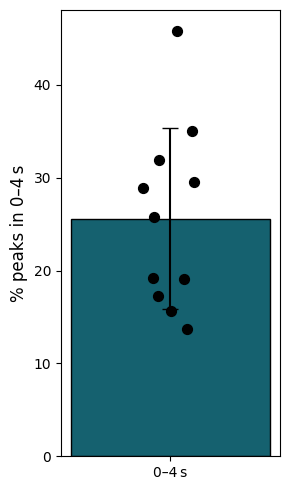

In [39]:
import matplotlib.pyplot as plt

col = f'Pct_Peaks_0to{int(window_post)}s'
mean_pct = pct_df[col].mean()
std_pct  = pct_df[col].std(ddof=1)

fig, ax = plt.subplots(figsize=(3,5))

# mean bar
ax.bar(0, mean_pct,
       yerr=std_pct,
       capsize=6,
       width=0.3,
       color=brain_region,  # e.g. '#15616F'
       edgecolor='black')

# overlay individual mice
for pct in pct_df[col]:
    ax.scatter(0 + np.random.uniform(-0.05,0.05), pct,
               color='black', s=50, zorder=5)

ax.set_xticks([0])
ax.set_xticklabels([f'0–{int(window_post)} s'])
ax.set_ylabel(f'% peaks in 0–{int(window_post)} s', fontsize=12)
plt.tight_layout()
plt.show()
